### Data Cleaning 
Medical Readmission Data

Research Question: What patient demographic is at highest risk for readmission?

By Stephanie Nguyen

In [ ]:
# importing all libraries and packages
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.decomposition import PCA

pd.set_option('display.max_columns',None)

# import medical_raw_data.csv data set
df_raw = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\2. Data Cleaning with Python\Data\medical_raw_data.csv")


In [ ]:
df_raw.shape

(10000, 53)

In [ ]:
# get overview of columns and data types in dataset
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   CaseOrder           10000 non-null  int64  
 2   Customer_id         10000 non-null  object 
 3   Interaction         10000 non-null  object 
 4   UID                 10000 non-null  object 
 5   City                10000 non-null  object 
 6   State               10000 non-null  object 
 7   County              10000 non-null  object 
 8   Zip                 10000 non-null  int64  
 9   Lat                 10000 non-null  float64
 10  Lng                 10000 non-null  float64
 11  Population          10000 non-null  int64  
 12  Area                10000 non-null  object 
 13  Timezone            10000 non-null  object 
 14  Job                 10000 non-null  object 
 15  Children            7412 non-null   float64
 16  Age  

In [ ]:
df_raw.head()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1.0,53.0,"Some College, Less than 1 Year",Full Time,86575.93,Divorced,Male,No,17.802330,6,0,0,NaN,Emergency Admission,Yes,No,Medium,0.0,Yes,Yes,No,Yes,1.0,Yes,No,Yes,Blood Work,10.585770,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3.0,51.0,"Some College, 1 or More Years, No Degree",Full Time,46805.99,Married,Female,No,18.994640,4,2,1,No,Emergency Admission,Yes,No,High,1.0,No,No,No,No,NaN,No,Yes,No,Intravenous,15.129562,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3.0,53.0,"Some College, 1 or More Years, No Degree",Retired,14370.14,Widowed,Female,No,17.415889,4,1,0,No,Elective Admission,Yes,No,Medium,1.0,No,Yes,No,No,NaN,No,No,No,Blood Work,4.772177,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0.0,78.0,GED or Alternative Credential,Retired,39741.49,Married,Male,No,17.420079,4,1,0,No,Elective Admission,No,Yes,Medium,0.0,Yes,No,No,No,NaN,No,Yes,Yes,Blood Work,1.714879,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,NaN,22.0,Regular High School Diploma,Full Time,1209.56,Widowed,Female,No,16.870524,5,0,2,Yes,Elective Admission,No,No,Low,0.0,No,No,Yes,No,0.0,Yes,No,No,CT Scan,1.254807,1885.655137,3716.525786,2,1,3,3,5,3,4,3


# Detecting Duplicates

In [ ]:
# get duplicates across all columns
df_raw.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [ ]:
# count duplicates, if any
df_raw.duplicated().value_counts()

False    10000
dtype: int64

In [ ]:
# check for duplicates, refined for patient identifying columns
column_names = ['Lat','Lng','Job','Income','Gender'] 
duplicates2 = df_raw.duplicated(subset = column_names, keep = False)
df_raw[duplicates2].sort_values(by = 'Lat')

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8


In [ ]:
# checking for duplicates in individual columns
column_names = ['Interaction'] 
duplicates2 = df_raw.duplicated(subset = column_names, keep = False)
df_raw[duplicates2].sort_values(by = 'Interaction')

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8


In [ ]:
# overview of values in dataframe 
col = df_raw.columns.values.tolist()
for col in df_raw:
    print(df_raw[col].unique())

[    1     2     3 ...  9998  9999 10000]
[    1     2     3 ...  9998  9999 10000]
['C412403' 'Z919181' 'F995323' ... 'R778890' 'E344109' 'I569847']
['8cd49b13-f45a-4b47-a2bd-173ffa932c2f'
 'd2450b70-0337-4406-bdbb-bc1037f1734c'
 'a2057123-abf5-4a2c-abad-8ffe33512562' ...
 '1d79569d-8e0f-4180-a207-d67ee4527d26'
 'f5a68e69-2a60-409b-a92f-ac0847b27db0'
 'bc482c02-f8c9-4423-99de-3db5e62a18d5']
['3a83ddb66e2ae73798bdf1d705dc0932' '176354c5eef714957d486009feabf195'
 'e19a0fa00aeda885b8a436757e889bc9' ... '41b770aeee97a5b9e7f69c906a8119d7'
 '2bb491ef5b1beb1fed758cc6885c167a' '95663a202338000abdf7e09311c2a8a1']
['Eva' 'Marianna' 'Sioux Falls' ... 'Milmay' 'Quinn' 'Coraopolis']
['AL' 'FL' 'SD' 'MN' 'VA' 'OK' 'OH' 'MS' 'WI' 'IA' 'CA' 'IN' 'MO' 'MI'
 'NE' 'PA' 'AR' 'WV' 'KS' 'MA' 'KY' 'NY' 'VT' 'DC' 'IL' 'ND' 'SC' 'AK'
 'NM' 'NH' 'GA' 'NC' 'MD' 'TN' 'WA' 'TX' 'CO' 'NJ' 'LA' 'OR' 'AZ' 'ME'
 'ID' 'UT' 'RI' 'MT' 'PR' 'NV' 'CT' 'HI' 'WY' 'DE']
['Morgan' 'Jackson' 'Minnehaha' ... 'Navarro' 'Los Alam

# Treating Duplicates

If duplicates were found the DROP function would have been used to remove the values from the dataset.

# Detecting Missingness 
1) Detect the missingness in the dataframe
2) Detect the missingness in the individual columns (variables)
3) Count (sum) the number of null values in each variable

In [ ]:
# return missing values
df_raw.isna()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


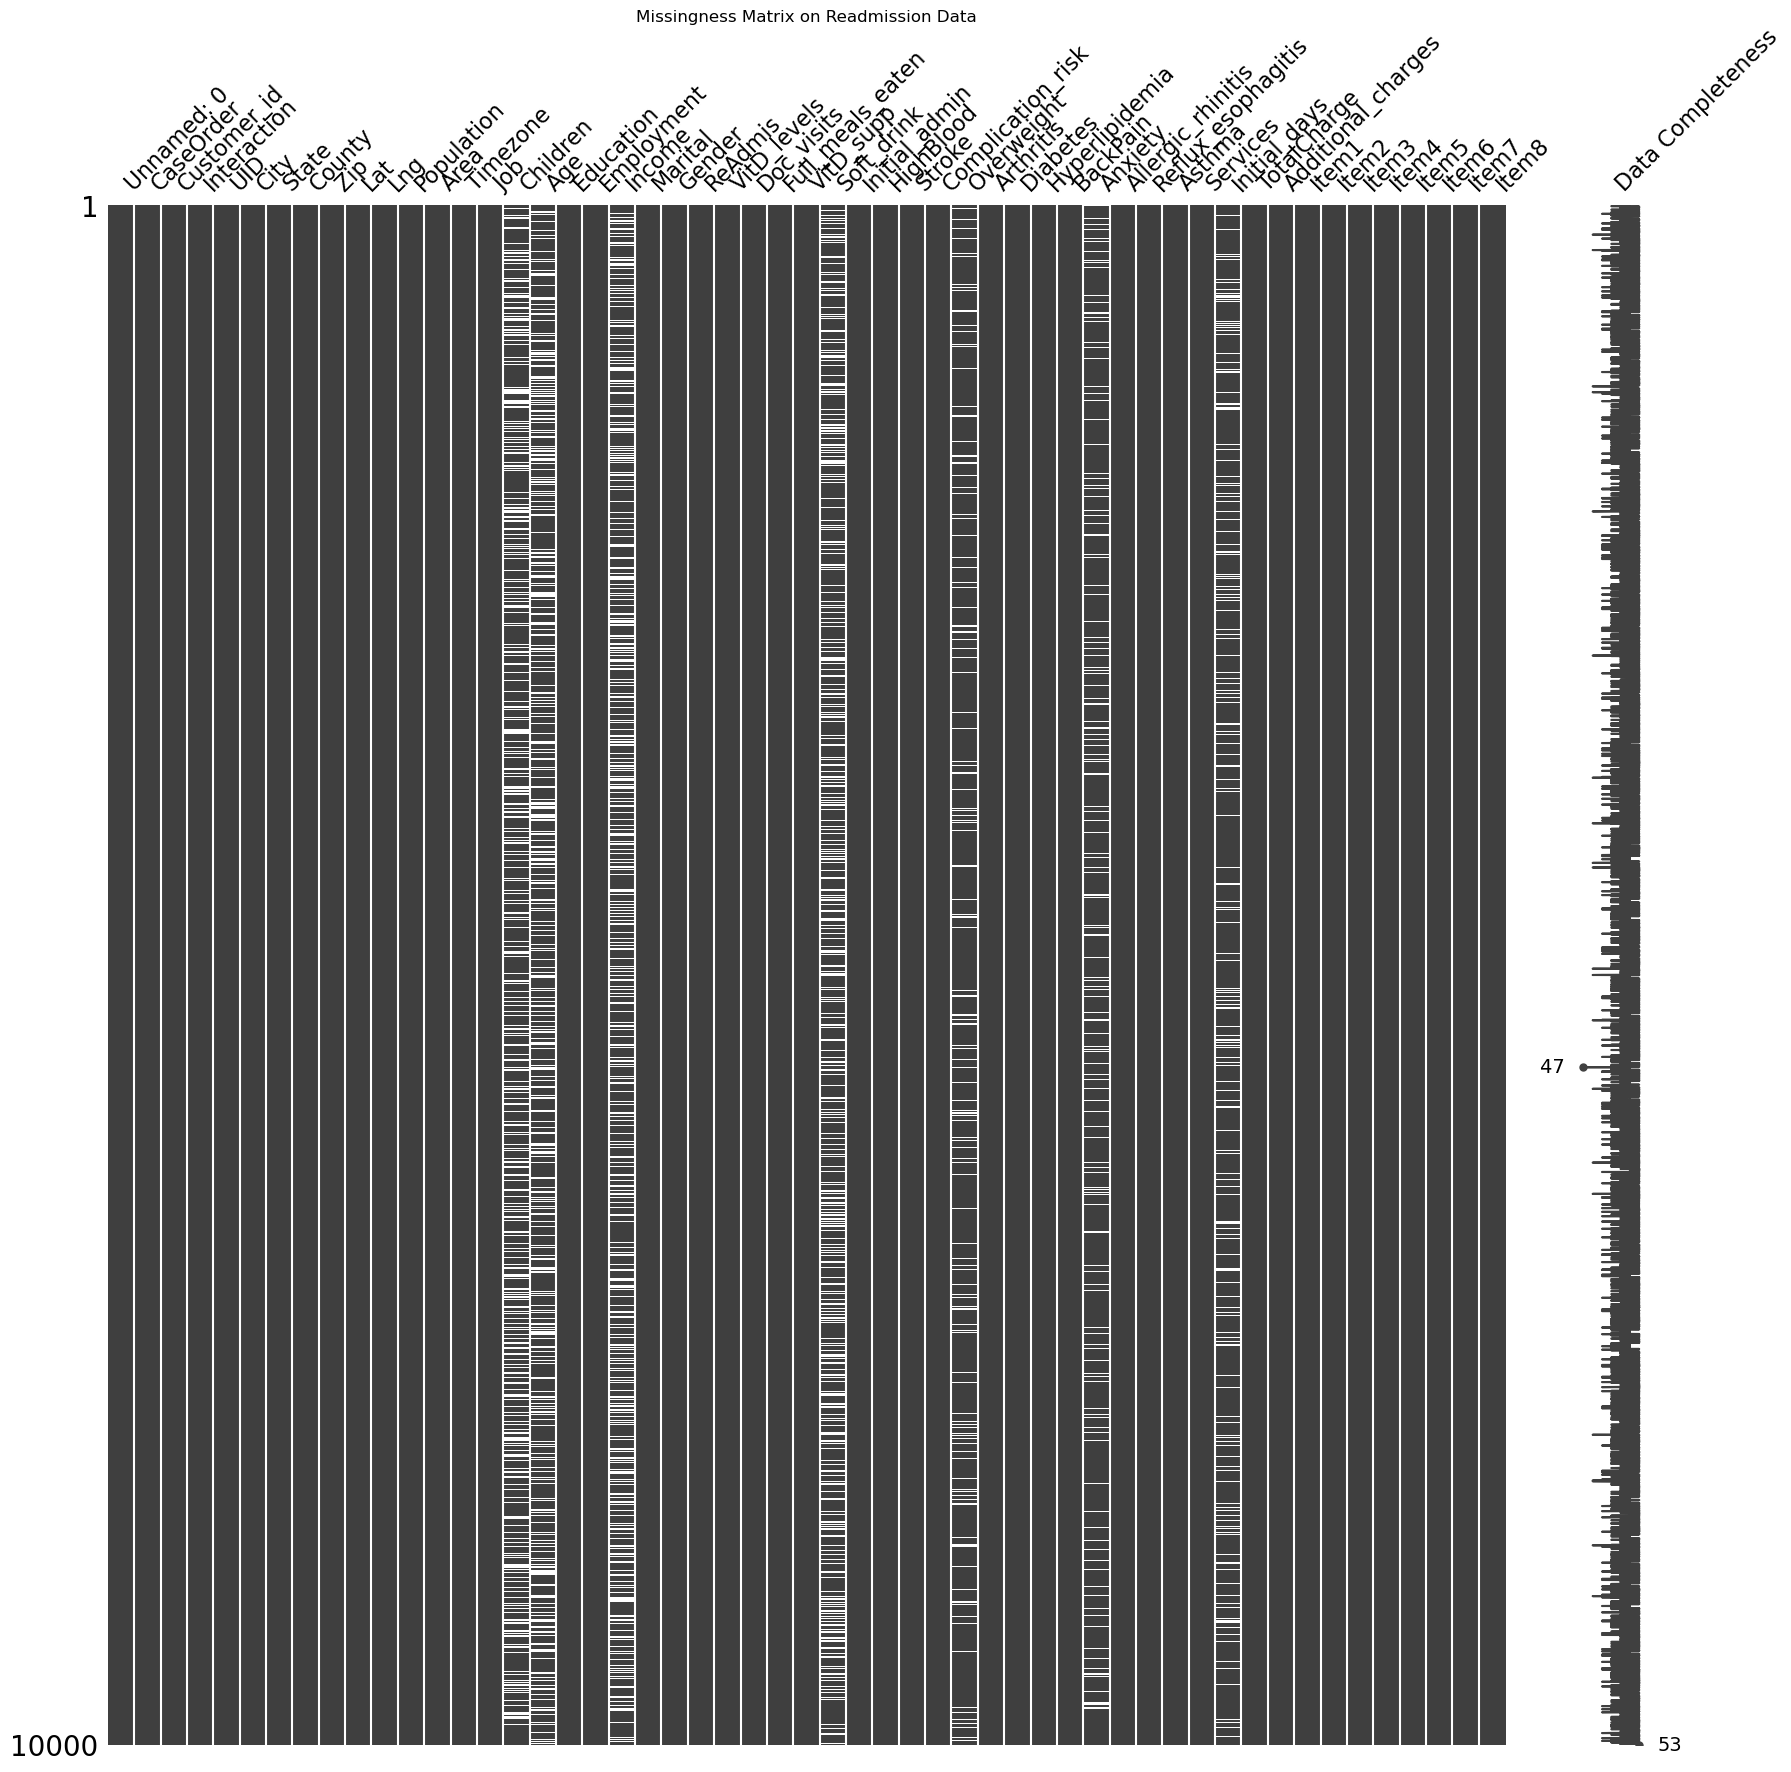

In [ ]:
# visualize missingness from readmission data
msno.matrix(df_raw, labels = True, figsize = (20,20))
plt.title('Missingness Matrix on Readmission Data')
# plt.savefig('Missingness Matrix on Readmission Data.png')
plt.show()

In [ ]:
# get summary of missingness in readmission data
# How many records are missing from each column?
df_raw.isna().sum()

Unnamed: 0               0
CaseOrder                0
Customer_id              0
Interaction              0
UID                      0
City                     0
State                    0
County                   0
Zip                      0
Lat                      0
Lng                      0
Population               0
Area                     0
Timezone                 0
Job                      0
Children              2588
Age                   2414
Education                0
Employment               0
Income                2464
Marital                  0
Gender                   0
ReAdmis                  0
VitD_levels              0
Doc_visits               0
Full_meals_eaten         0
VitD_supp                0
Soft_drink            2467
Initial_admin            0
HighBlood                0
Stroke                   0
Complication_risk        0
Overweight             982
Arthritis                0
Diabetes                 0
Hyperlipidemia           0
BackPain                 0
A

In [ ]:
# percentage of missingness
df_raw.isna().mean() * 100

Unnamed: 0             0.00
CaseOrder              0.00
Customer_id            0.00
Interaction            0.00
UID                    0.00
City                   0.00
State                  0.00
County                 0.00
Zip                    0.00
Lat                    0.00
Lng                    0.00
Population             0.00
Area                   0.00
Timezone               0.00
Job                    0.00
Children              25.88
Age                   24.14
Education              0.00
Employment             0.00
Income                24.64
Marital                0.00
Gender                 0.00
ReAdmis                0.00
VitD_levels            0.00
Doc_visits             0.00
Full_meals_eaten       0.00
VitD_supp              0.00
Soft_drink            24.67
Initial_admin          0.00
HighBlood              0.00
Stroke                 0.00
Complication_risk      0.00
Overweight             9.82
Arthritis              0.00
Diabetes               0.00
Hyperlipidemia      

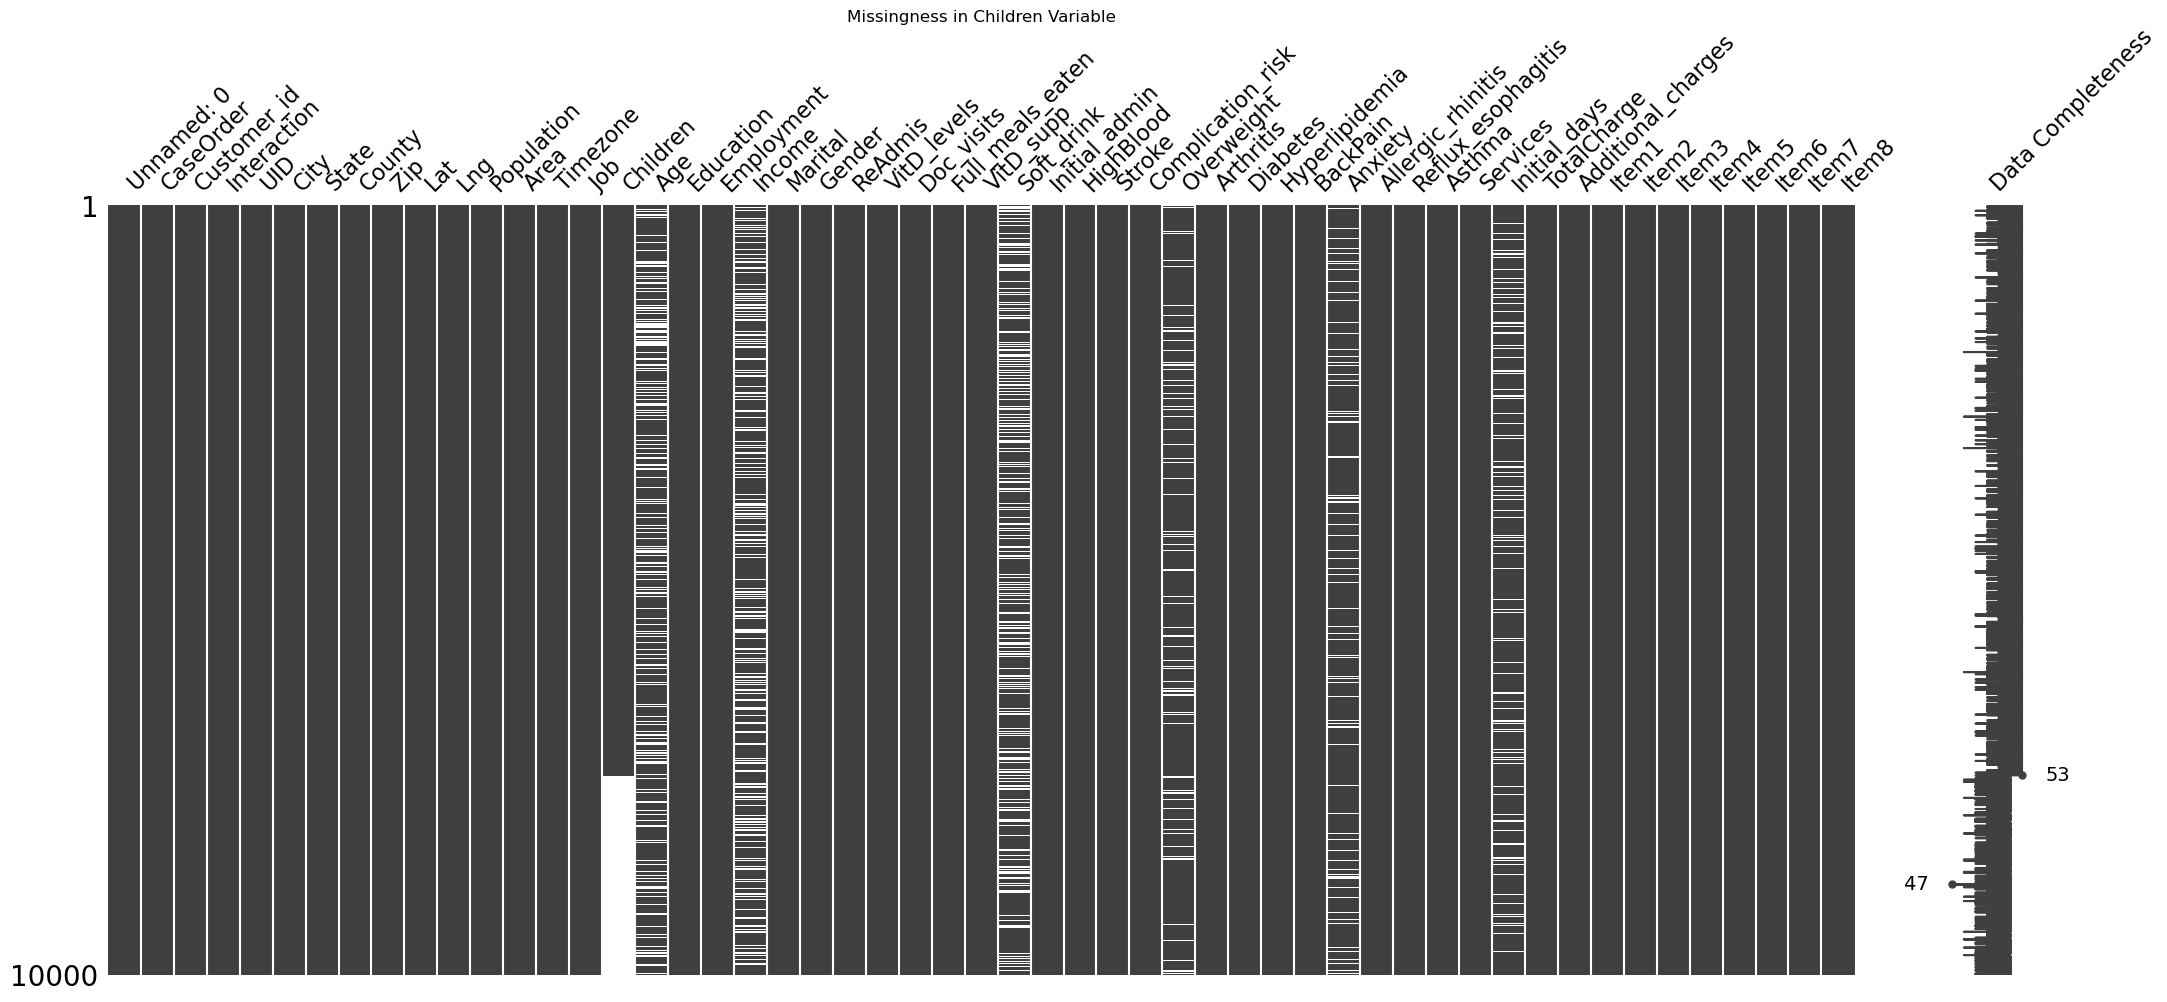

In [ ]:
# visualize missingness sorted on Children variable
sorted_df_raw = df_raw.sort_values(by = 'Children')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Children Variable')
plt.savefig('Missingness in Children Variable.png')
plt.show()

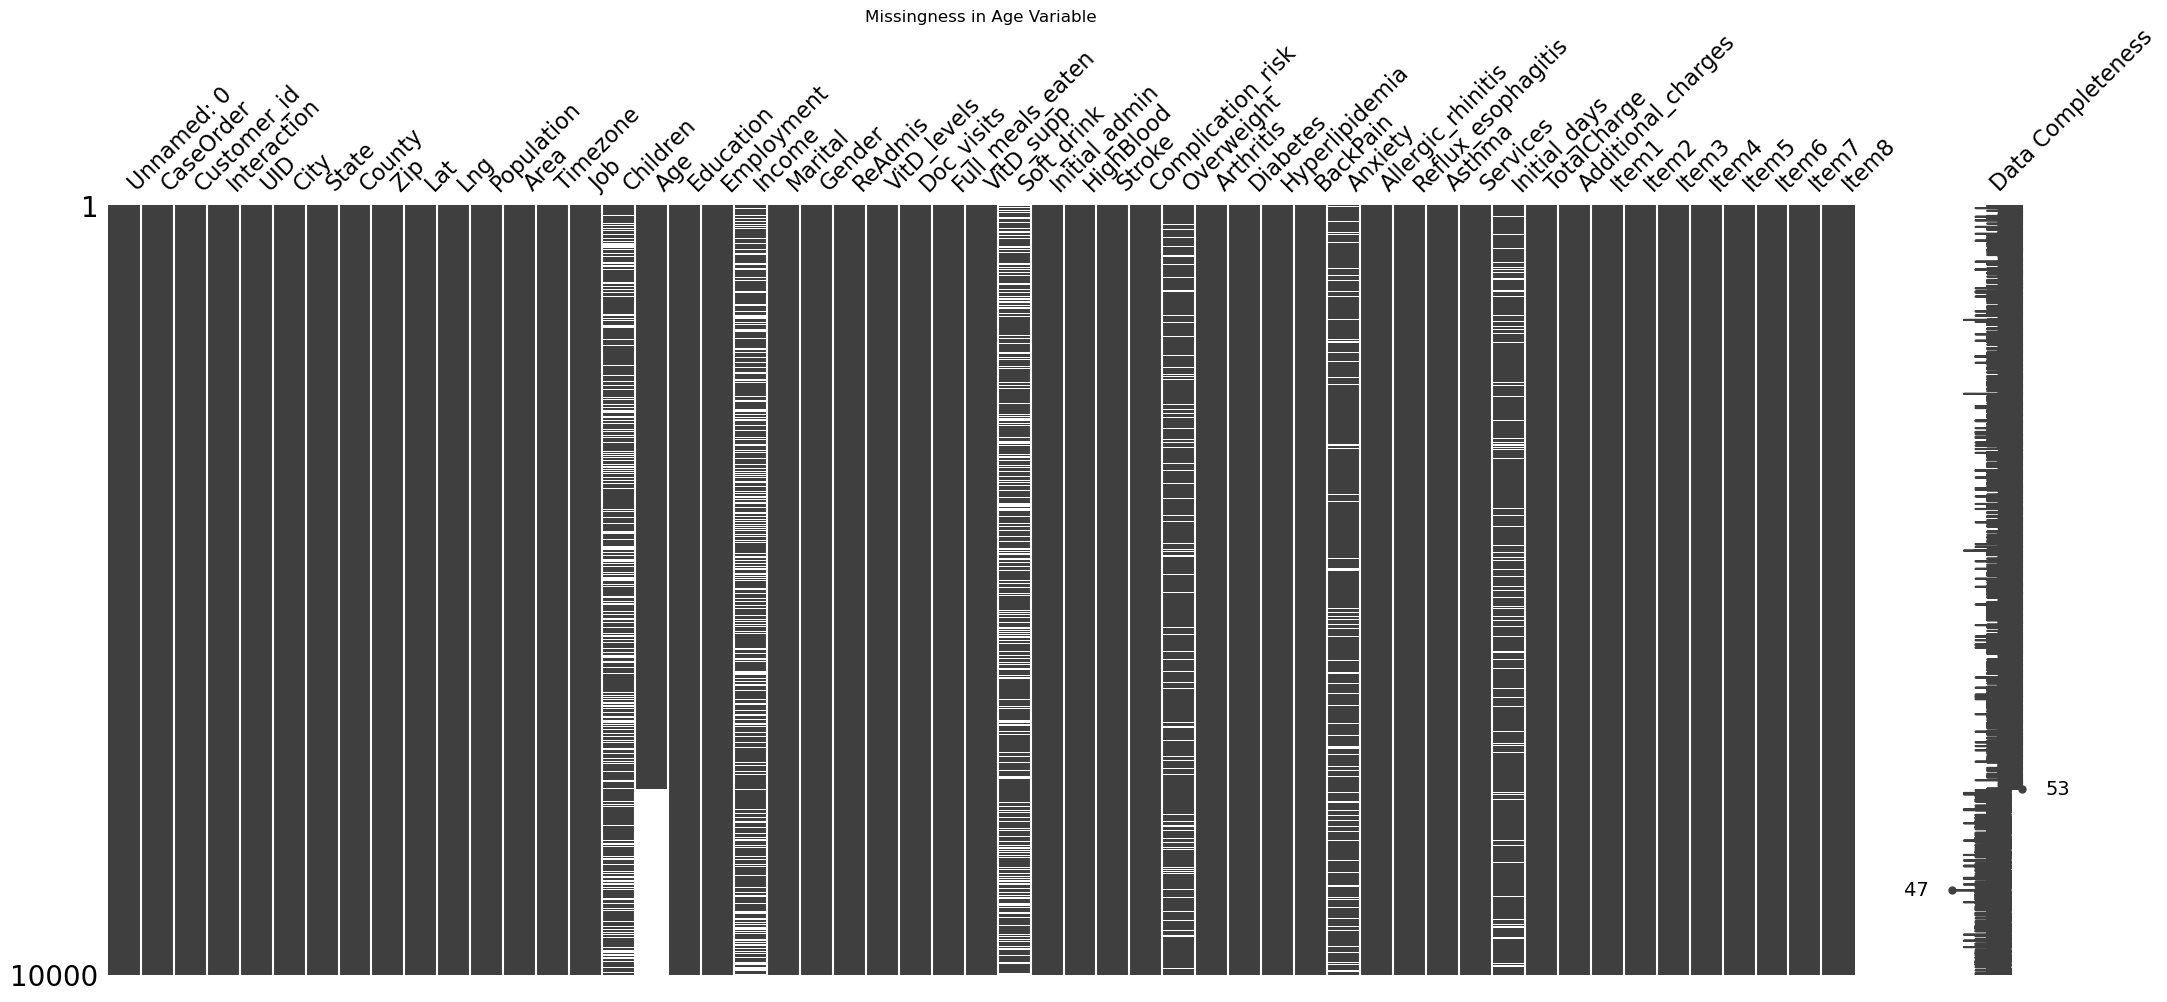

In [ ]:
# visualize missingness sorted on Age variable
sorted_df_raw = df_raw.sort_values(by = 'Age')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Age Variable')
plt.savefig('Missingness in Age Variable.png')
plt.show()

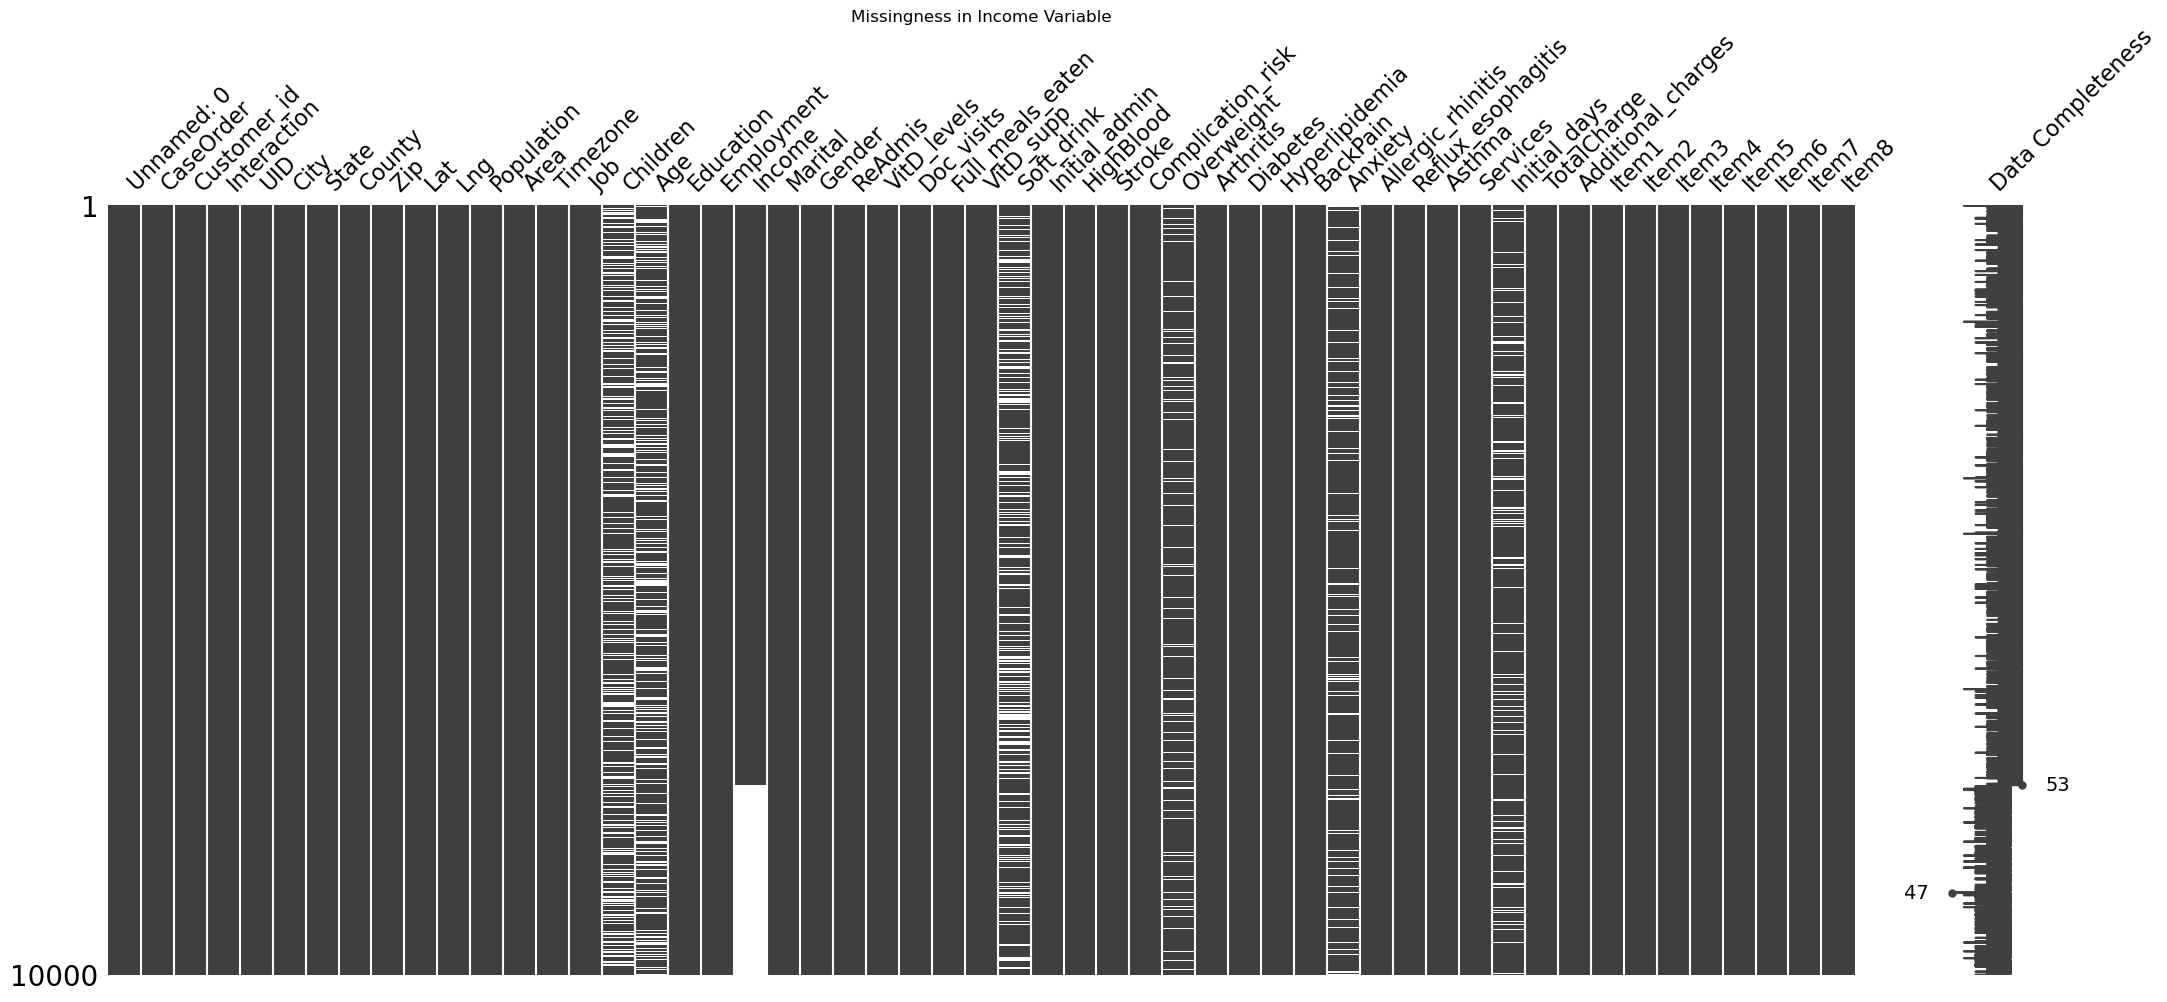

In [ ]:
# visualize missingness sorted on Age variable
sorted_df_raw = df_raw.sort_values(by = 'Income')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Income Variable')
plt.savefig('Missingness in Income Variable.png')
plt.show()

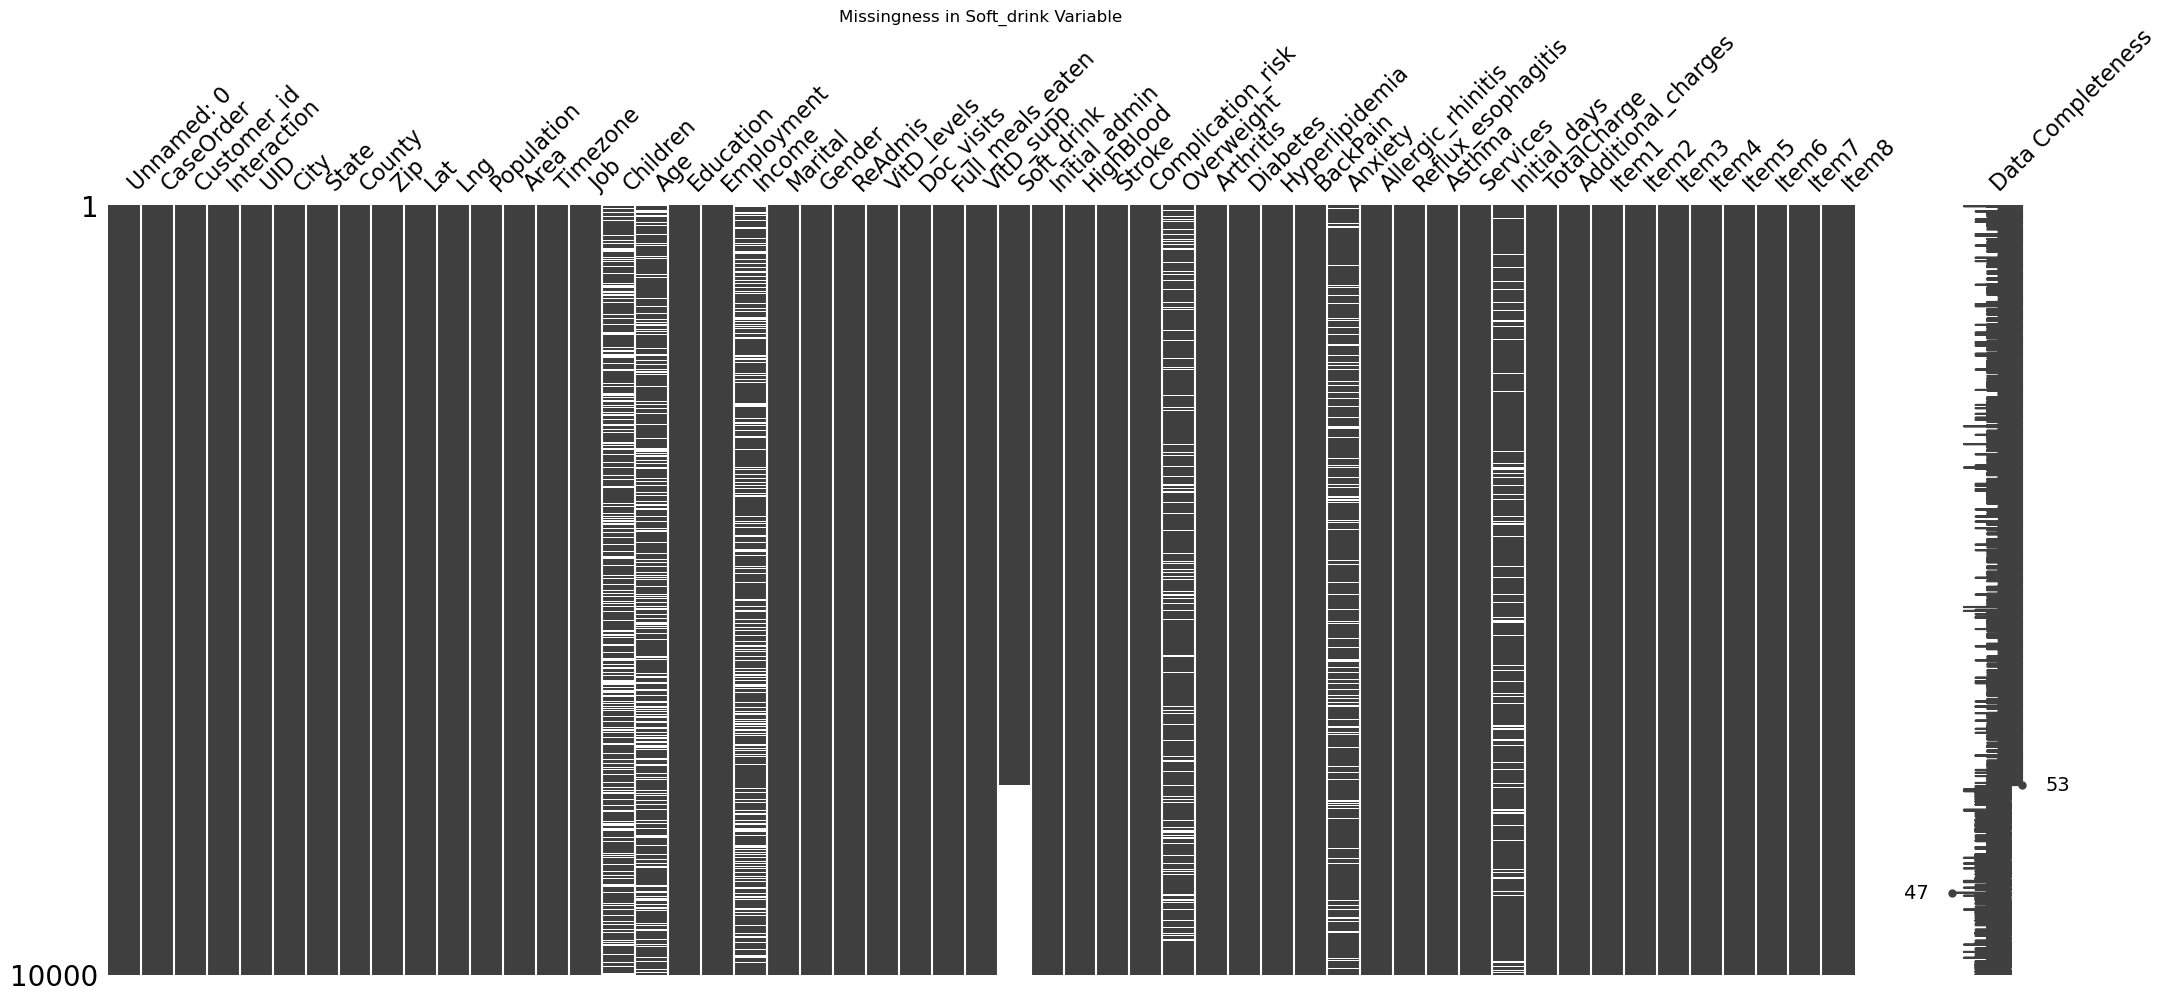

In [ ]:
# visualize missingness sorted on Soft_drink variable
sorted_df_raw = df_raw.sort_values(by = 'Soft_drink')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Soft_drink Variable')
plt.savefig('Missingness in Soft_drink Variable.png')
plt.show()

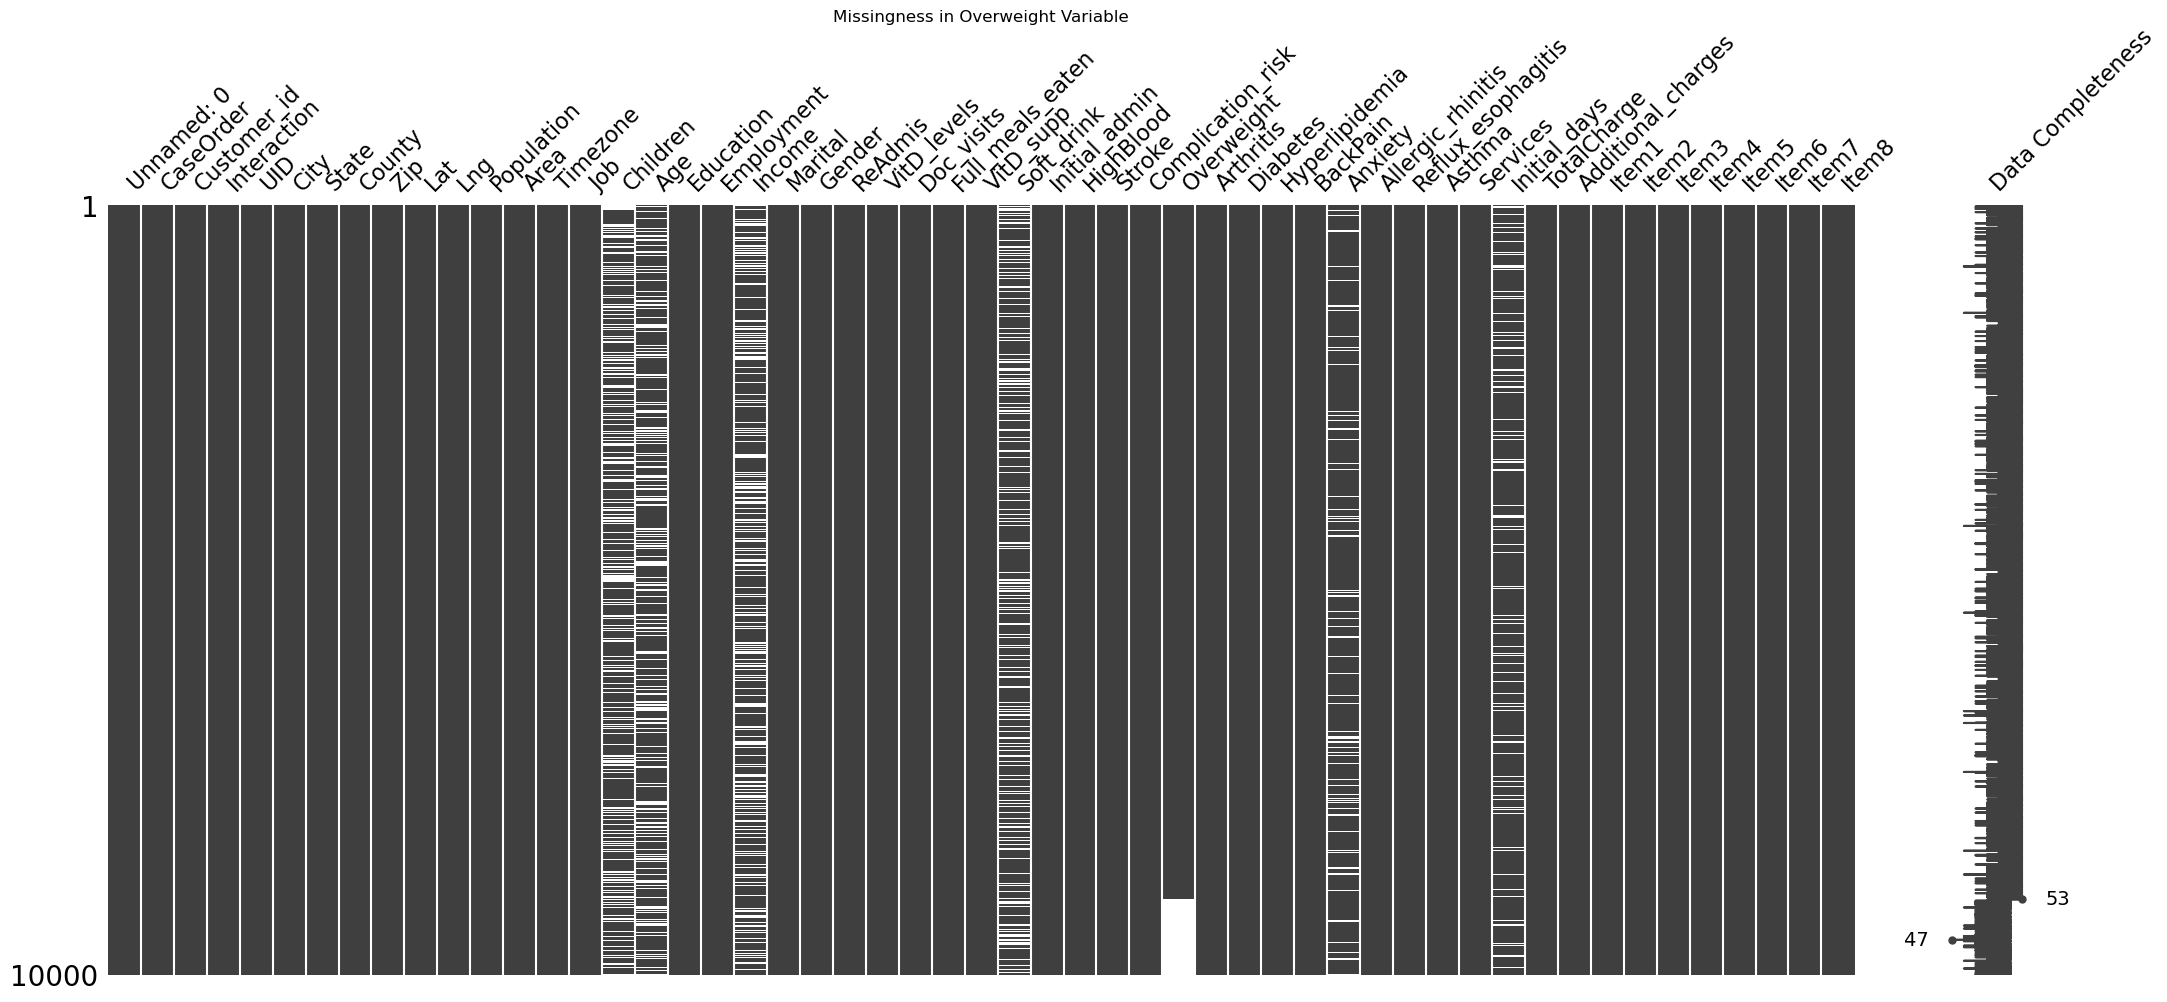

In [ ]:
# visualize missingness sorted on Overweight variable
sorted_df_raw = df_raw.sort_values(by = 'Overweight')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Overweight Variable')
plt.savefig('Missingness in Overweight Variable.png')
plt.show()

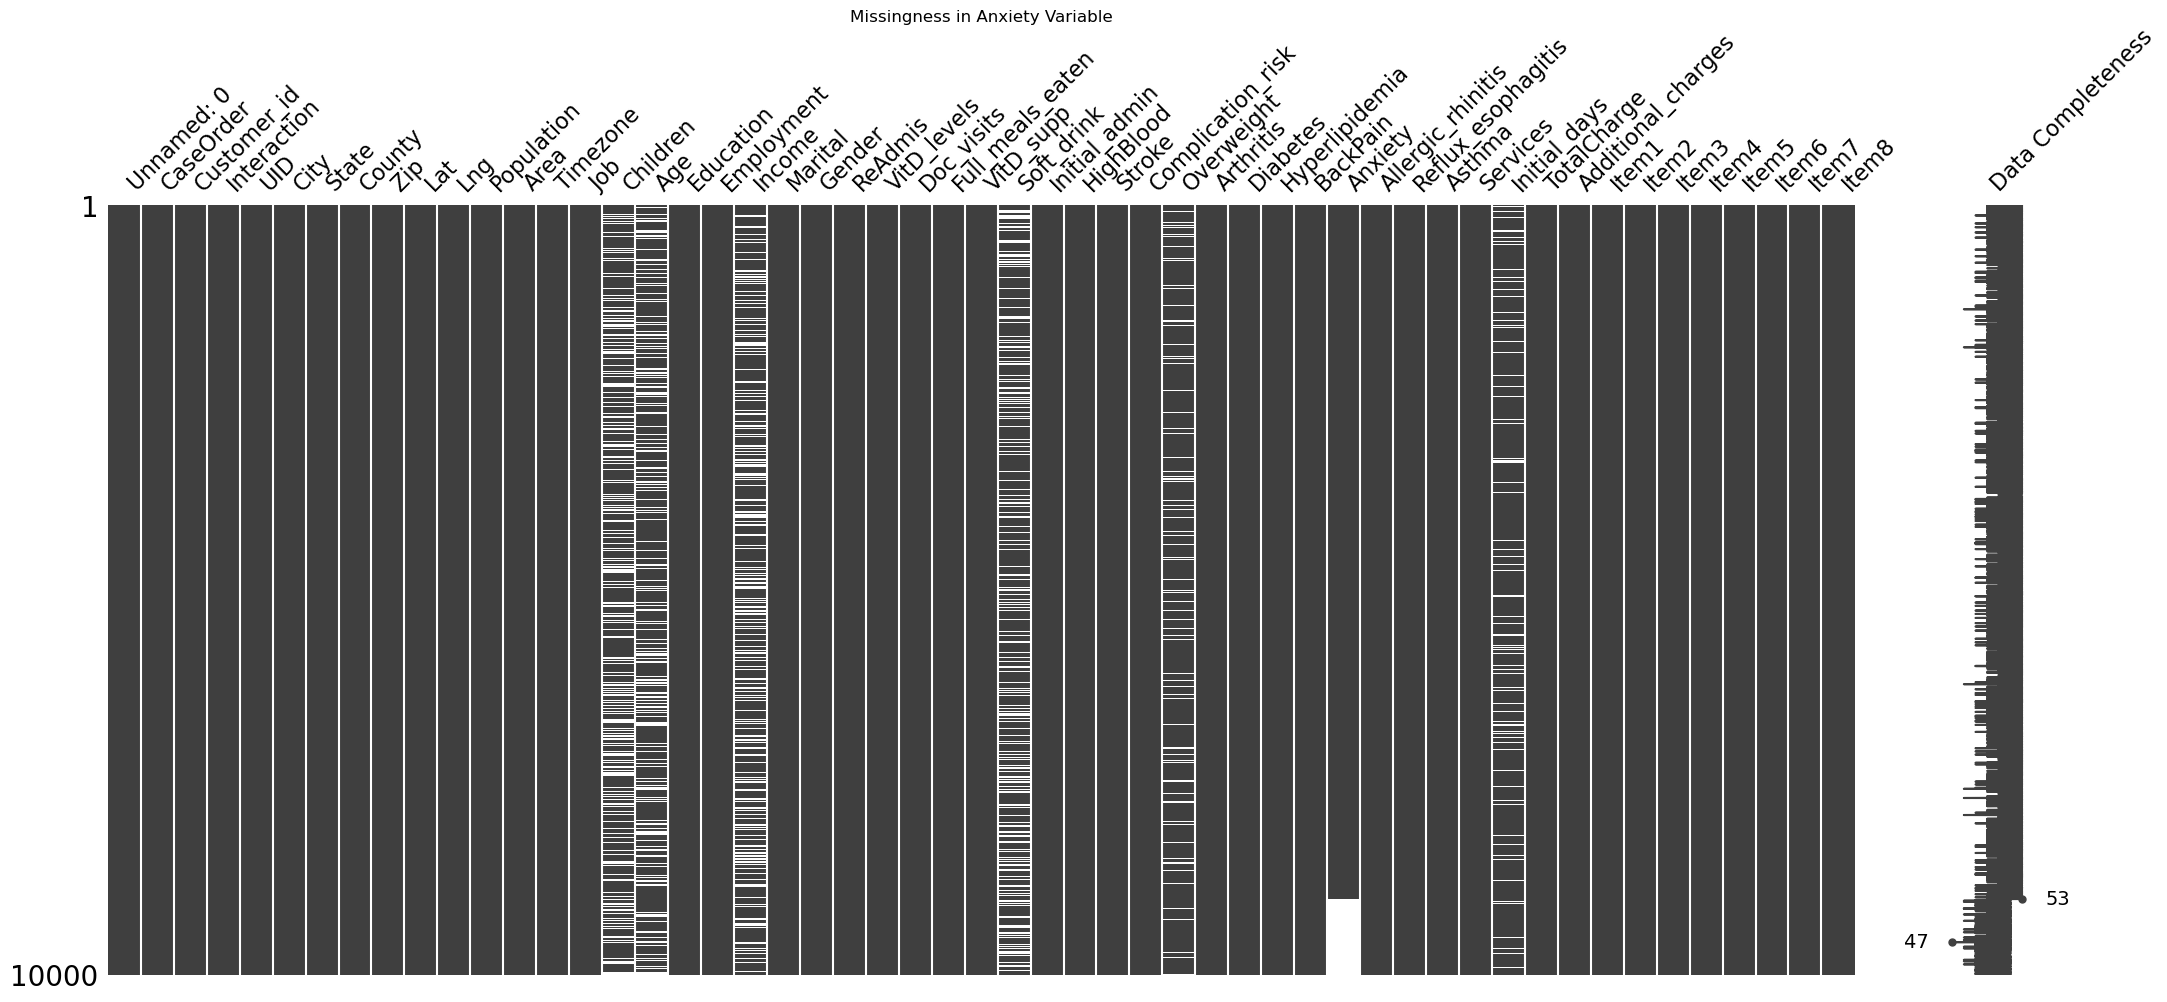

In [ ]:
# visualize missingness sorted on Anxiety variable
sorted_df_raw = df_raw.sort_values(by = 'Anxiety')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Anxiety Variable')
plt.savefig('Missingness in Anxiety Variable.png')
plt.show()

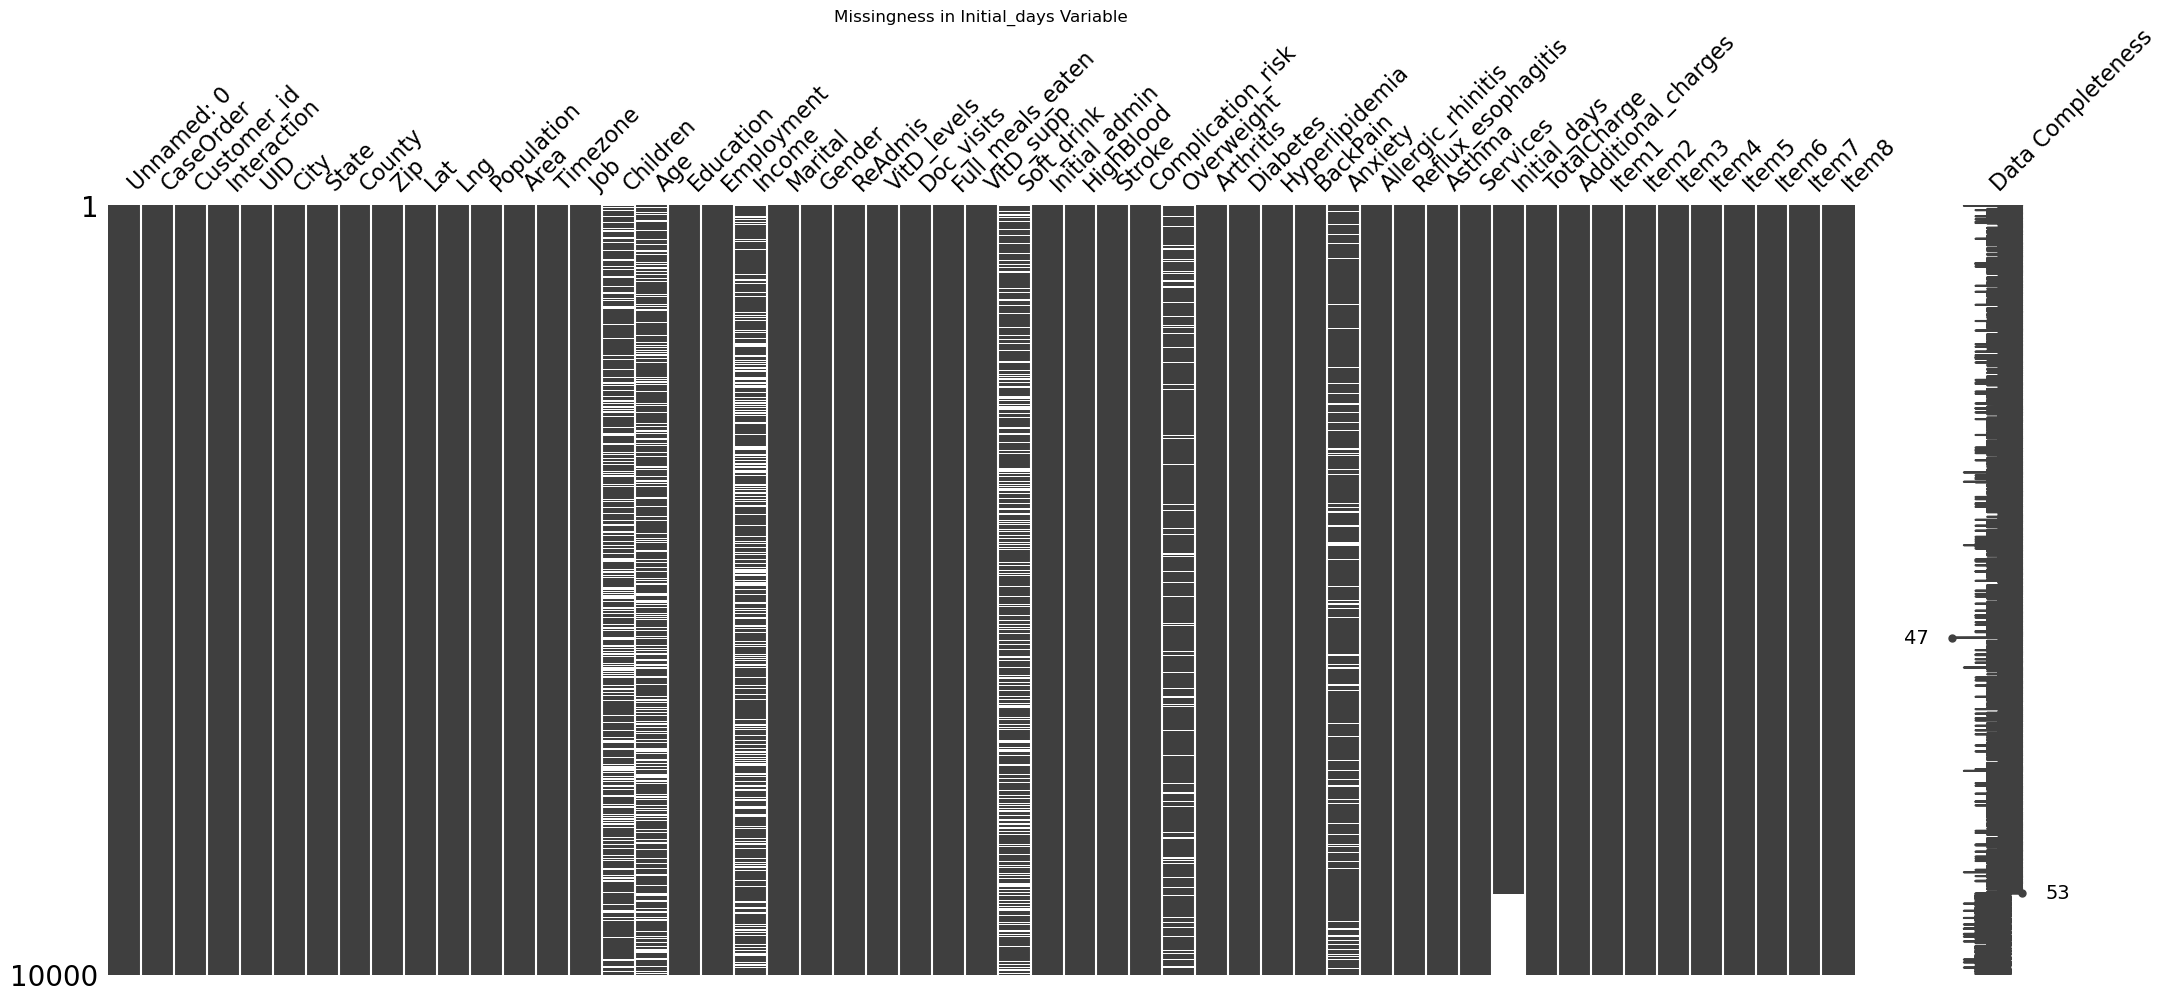

In [ ]:
# visualize missingness sorted on Initial_days variable
sorted_df_raw = df_raw.sort_values(by = 'Initial_days')
msno.matrix(sorted_df_raw, labels = True)
plt.title('Missingness in Initial_days Variable')
plt.savefig('Missingness in Initial_days Variable.png')
plt.show()

# Treating the missingness
1) Determine the distribution shape
2) Choose imputation method
3) Replace null values with stats value
4) Compare the mean and median before and after the imputation
5) Compare the distribution shapes before and after the imputation

Note: convert categorical values into numeric

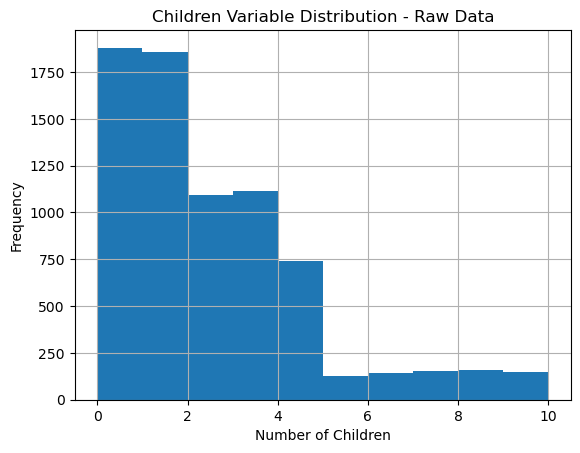

In [ ]:
# plot a histogram for each variable to get the distribution shape
# choose imputation method based on data type and distribution shape

# Children has a skewed distribution
df_raw.hist(column = 'Children')
plt.title('Children Variable Distribution - Raw Data')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
# plt.savefig('Children Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Children'].describe()

count    7412.000000
mean        2.098219
std         2.155427
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        10.000000
Name: Children, dtype: float64

In [ ]:
df_raw['Children'].median()

1.0

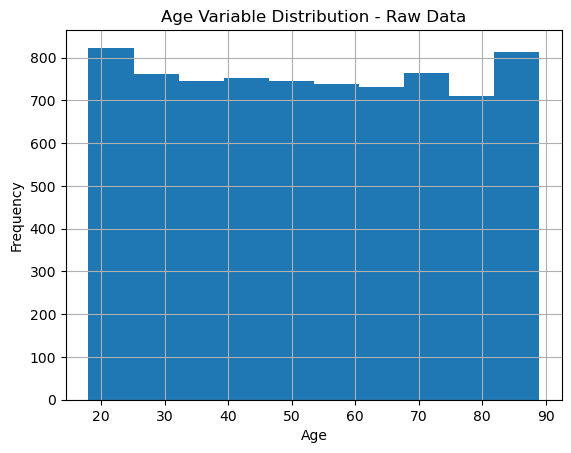

In [ ]:
# Age has a normal (uniform) distribution
df_raw.hist(column = 'Age')
plt.title('Age Variable Distribution - Raw Data')
plt.xlabel('Age')
plt.ylabel('Frequency')
# plt.savefig('Age Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Age'].describe()

count    7586.000000
mean       53.295676
std        20.659182
min        18.000000
25%        35.000000
50%        53.000000
75%        71.000000
max        89.000000
Name: Age, dtype: float64

In [ ]:
df_raw['Age'].median()

53.0

In [ ]:
# convert categorical column containing missing values to numeric values
df_raw['Soft_drink'].replace(['Yes', 'No'],[1,0], inplace = True)
df_raw['Soft_drink']

0       NaN
1       0.0
2       0.0
3       0.0
4       1.0
       ... 
9995    0.0
9996    0.0
9997    1.0
9998    0.0
9999    0.0
Name: Soft_drink, Length: 10000, dtype: float64

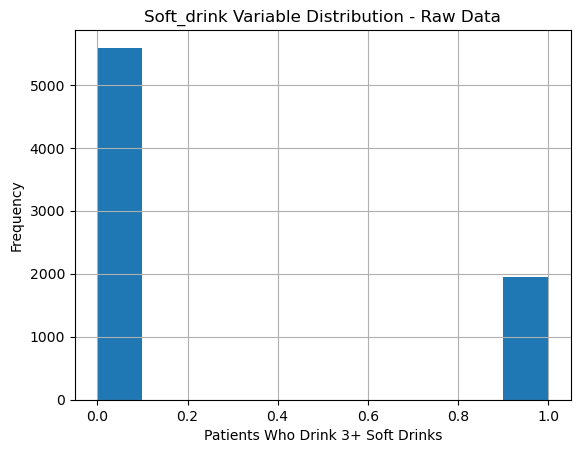

In [ ]:
# Soft_drink has a skewed distribution
df_raw.hist(column = 'Soft_drink')
plt.title('Soft_drink Variable Distribution - Raw Data')
plt.xlabel('Patients Who Drink 3+ Soft Drinks')
plt.ylabel('Frequency')
# plt.savefig('Soft_drink Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Soft_drink'].describe()

count    7533.000000
mean        0.258065
std         0.437599
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Soft_drink, dtype: float64

In [ ]:
df_raw['Soft_drink'].median()

0.0

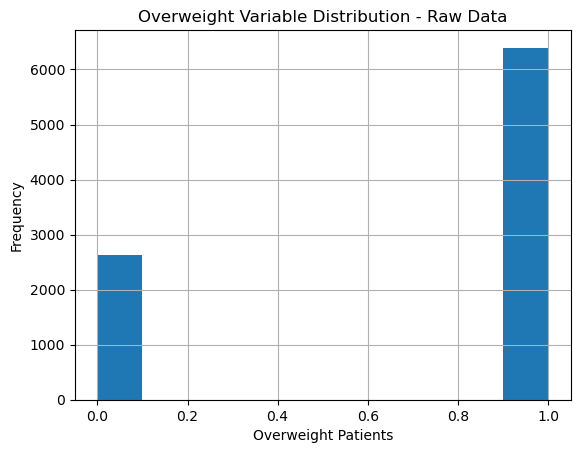

In [ ]:
# Overweight has a skewed distribution
df_raw.hist(column = 'Overweight')
plt.title('Overweight Variable Distribution - Raw Data')
plt.xlabel('Overweight Patients')
plt.ylabel('Frequency')
# plt.savefig('Overweight Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Overweight'].describe()

count    9018.000000
mean        0.709137
std         0.454186
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Overweight, dtype: float64

In [ ]:
df_raw['Overweight'].median()

1.0

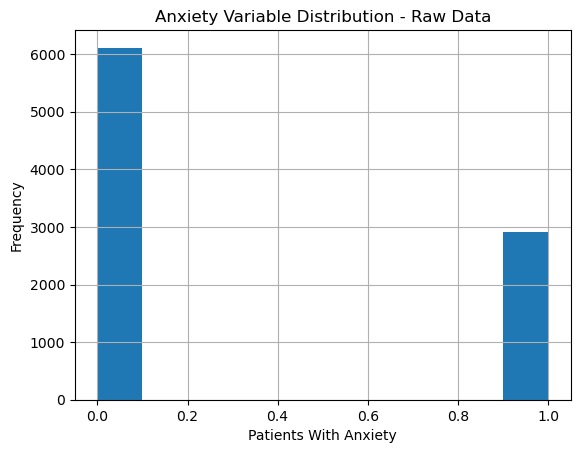

In [ ]:
# Anxiety has a skewed distribution
df_raw.hist(column = 'Anxiety')
plt.title('Anxiety Variable Distribution - Raw Data')
plt.xlabel('Patients With Anxiety')
plt.ylabel('Frequency')
# plt.savefig('Anxiety Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Anxiety'].describe()

count    9016.000000
mean        0.322316
std         0.467389
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Anxiety, dtype: float64

In [ ]:
df_raw['Anxiety'].median()

0.0

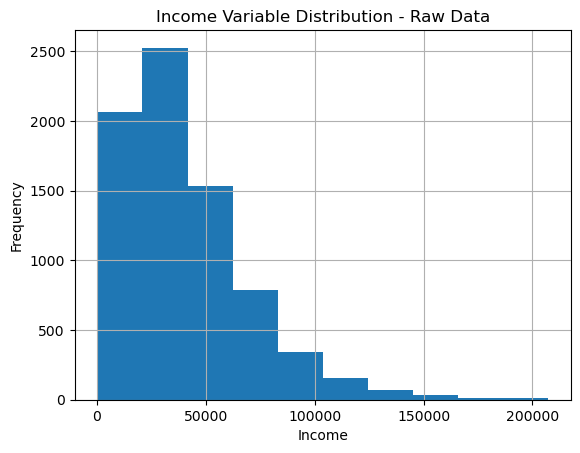

In [ ]:
# Income has a skewed distribution
df_raw.hist(column = 'Income')
plt.title('Income Variable Distribution - Raw Data')
plt.xlabel('Income')
plt.ylabel('Frequency')
# plt.savefig('Income Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Income'].describe()

count      7536.000000
mean      40484.438268
std       28664.861050
min         154.080000
25%       19450.792500
50%       33942.280000
75%       54075.235000
max      207249.130000
Name: Income, dtype: float64

In [ ]:
df_raw['Income'].median()

33942.28

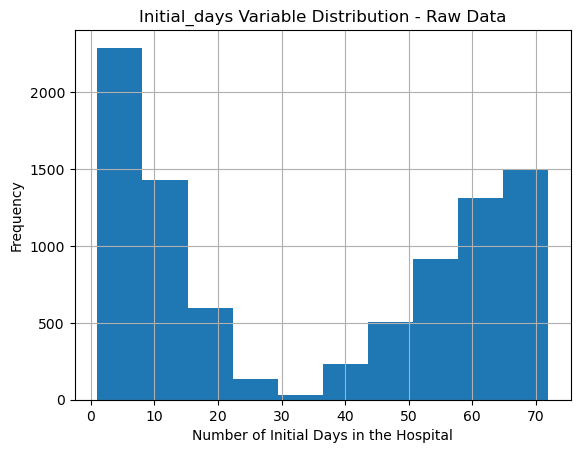

In [ ]:
# Initial_days has a bimodal distribution
df_raw.hist(column = 'Initial_days')
plt.title('Initial_days Variable Distribution - Raw Data')
plt.xlabel('Number of Initial Days in the Hospital')
plt.ylabel('Frequency')
# plt.savefig('Initial_days Variable Distribution - Raw Data.png')
plt.show()

In [ ]:
df_raw['Initial_days'].describe()

count    8944.000000
mean       34.432082
std        26.287050
min         1.001981
25%         7.911709
50%        34.446941
75%        61.124654
max        71.981486
Name: Initial_days, dtype: float64

In [ ]:
df_raw['Initial_days'].median()

34.44694129

In [ ]:
df_clean = df_raw

In [ ]:
# use fillna() to fill all NA values with a particular value (mean,median,mode)
df_clean['Children'].fillna(df_clean['Children'].median(), inplace = True)
df_clean['Age'].fillna(df_clean['Age'].mean(), inplace = True)
df_clean['Income'].fillna(df_clean['Income'].median(), inplace = True)
df_clean['Soft_drink'].fillna(df_clean['Soft_drink'].mode()[0], inplace = True)
df_clean['Overweight'].fillna(df_clean['Overweight'].mode()[0], inplace = True)
df_clean['Anxiety'].fillna(df_clean['Anxiety'].mode()[0], inplace = True)
df_clean['Initial_days'].fillna(df_clean['Initial_days'].median(), inplace = True)

In [ ]:
df_clean.isna().sum()

Unnamed: 0            0
CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
Timezone              0
Job                   0
Children              0
Age                   0
Education             0
Employment            0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
VitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services        

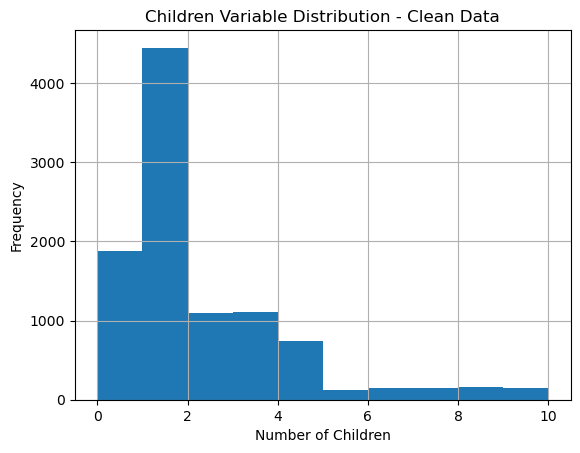

In [ ]:
# Children still has a skewed distribution with the cleanded data  
df_clean.hist(column = 'Children')
plt.title('Children Variable Distribution - Clean Data')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
# plt.savefig('Children Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Children'].describe()

count    10000.000000
mean         1.814000
std          1.916969
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         10.000000
Name: Children, dtype: float64

In [ ]:
df_clean['Children'].median()

1.0

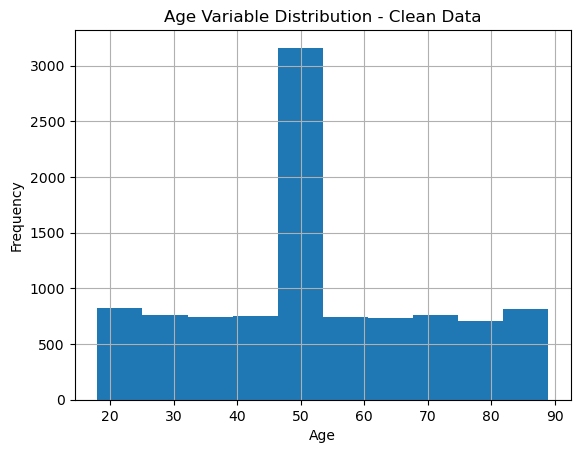

In [ ]:
# Age still has a relatively uniform distribution with the clean data
df_clean.hist(column = 'Age')
plt.title('Age Variable Distribution - Clean Data')
plt.xlabel('Age')
plt.ylabel('Frequency')
# plt.savefig('Age Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Age'].describe()

count    10000.000000
mean        53.295676
std         17.993375
min         18.000000
25%         41.000000
50%         53.295676
75%         65.000000
max         89.000000
Name: Age, dtype: float64

In [ ]:
df_clean['Age'].median()

53.29567624571579

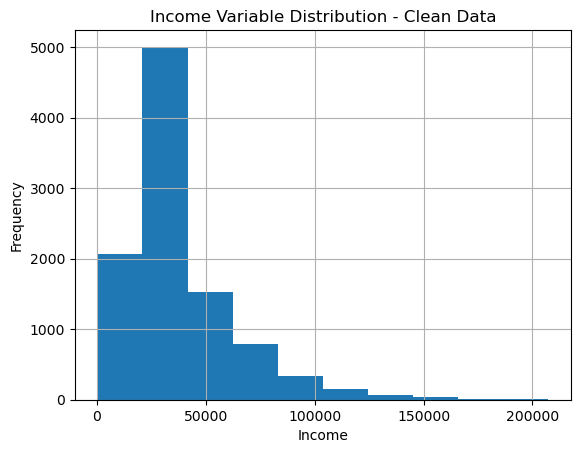

In [ ]:
# Income still has a skewed distribution with the cleaned data
df_clean.hist(column = 'Income')
plt.title('Income Variable Distribution - Clean Data')
plt.xlabel('Income')
plt.ylabel('Frequency')
# plt.savefig('Income Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Income'].describe()

count     10000.000000
mean      38872.450471
std       25042.796229
min         154.080000
25%       23956.162500
50%       33942.280000
75%       46466.797500
max      207249.130000
Name: Income, dtype: float64

In [ ]:
df_clean['Income'].median()

33942.28

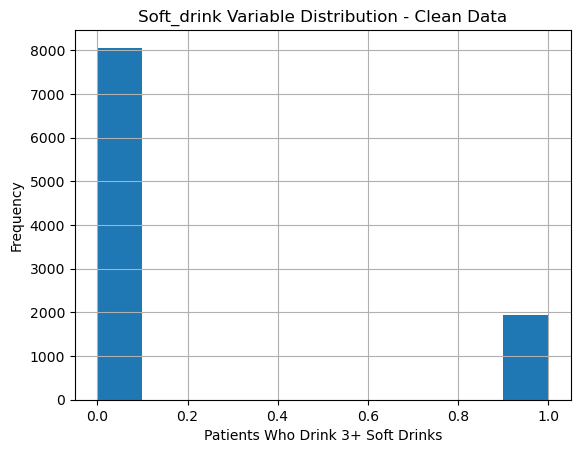

In [ ]:
# Soft_drink still has a skewed distribution with the cleaned data
df_clean.hist(column = 'Soft_drink')
plt.title('Soft_drink Variable Distribution - Clean Data')
plt.xlabel('Patients Who Drink 3+ Soft Drinks')
plt.ylabel('Frequency')
# plt.savefig('Soft_drink Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Soft_drink'].describe()

count    10000.000000
mean         0.194400
std          0.395758
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Soft_drink, dtype: float64

In [ ]:
df_clean['Soft_drink'].median()

0.0

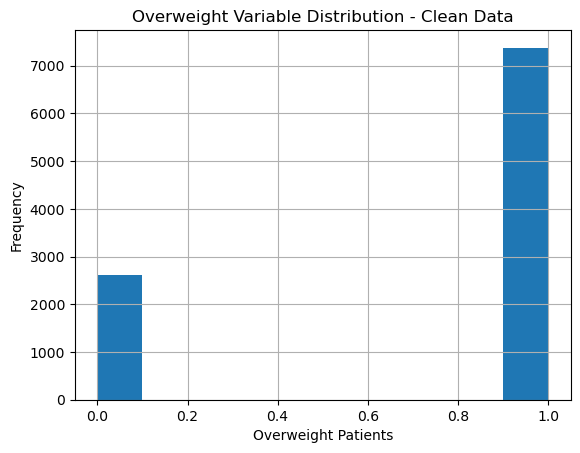

In [ ]:
# Overweight still has a skewed distribution with the cleaned data
df_clean.hist(column = 'Overweight')
plt.title('Overweight Variable Distribution - Clean Data')
plt.xlabel('Overweight Patients')
plt.ylabel('Frequency')
# plt.savefig('Overwight Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Overweight'].describe()

count    10000.000000
mean         0.737700
std          0.439907
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Overweight, dtype: float64

In [ ]:
df_clean['Overweight'].median()

1.0

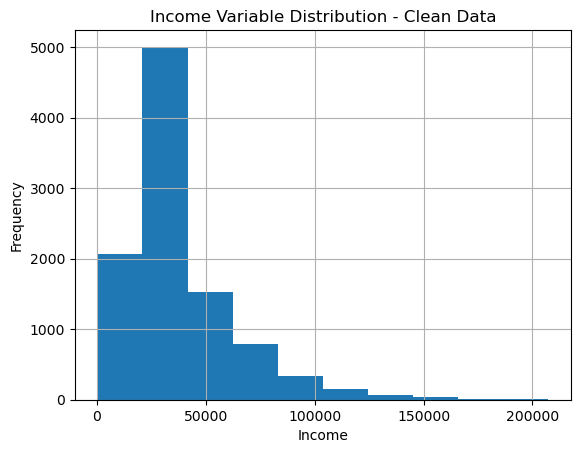

In [ ]:
# Income still has a skewed distribution with the cleaned data
df_clean.hist(column = 'Income')
plt.title('Income Variable Distribution - Clean Data')
plt.xlabel('Income')
plt.ylabel('Frequency')
# plt.savefig('Income Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Income'].describe()

count     10000.000000
mean      38872.450471
std       25042.796229
min         154.080000
25%       23956.162500
50%       33942.280000
75%       46466.797500
max      207249.130000
Name: Income, dtype: float64

In [ ]:
df_clean['Income'].median()

33942.28

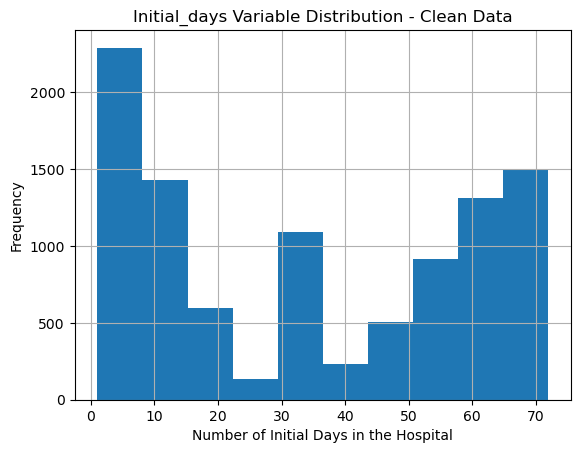

In [ ]:
# Initial_days still has a bimodal distribution with the cleaned data
df_clean.hist(column = 'Initial_days')
plt.title('Initial_days Variable Distribution - Clean Data')
plt.xlabel('Number of Initial Days in the Hospital')
plt.ylabel('Frequency')
# plt.savefig('Initial_days Variable Distribution - Clean Data.png')
plt.show()

In [ ]:
df_clean['Initial_days'].describe()

count    10000.000000
mean        34.433651
std         24.860232
min          1.001981
25%          8.928987
50%         34.446941
75%         59.459981
max         71.981486
Name: Initial_days, dtype: float64

In [ ]:
df_clean['Initial_days'].median()

34.44694129

In [ ]:
df_clean.head()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1.0,53.0,"Some College, Less than 1 Year",Full Time,86575.93,Divorced,Male,No,17.802330,6,0,0,0.0,Emergency Admission,Yes,No,Medium,0.0,Yes,Yes,No,Yes,1.0,Yes,No,Yes,Blood Work,10.585770,3191.048774,17939.403420,3,3,2,2,4,3,3,4
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3.0,51.0,"Some College, 1 or More Years, No Degree",Full Time,46805.99,Married,Female,No,18.994640,4,2,1,0.0,Emergency Admission,Yes,No,High,1.0,No,No,No,No,0.0,No,Yes,No,Intravenous,15.129562,4214.905346,17612.998120,3,4,3,4,4,4,3,3
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3.0,53.0,"Some College, 1 or More Years, No Degree",Retired,14370.14,Widowed,Female,No,17.415889,4,1,0,0.0,Elective Admission,Yes,No,Medium,1.0,No,Yes,No,No,0.0,No,No,No,Blood Work,4.772177,2177.586768,17505.192460,2,4,4,4,3,4,3,3
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0.0,78.0,GED or Alternative Credential,Retired,39741.49,Married,Male,No,17.420079,4,1,0,0.0,Elective Admission,No,Yes,Medium,0.0,Yes,No,No,No,0.0,No,Yes,Yes,Blood Work,1.714879,2465.118965,12993.437350,3,5,5,3,4,5,5,5
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1.0,22.0,Regular High School Diploma,Full Time,1209.56,Widowed,Female,No,16.870524,5,0,2,1.0,Elective Admission,No,No,Low,0.0,No,No,Yes,No,0.0,Yes,No,No,CT Scan,1.254807,1885.655137,3716.525786,2,1,3,3,5,3,4,3


# Detecting outliers
1) Detect the outliers using Z-scores, boxplots, and histograms
2) Count # of outliers in each variable
3) Apply a treatment method: retain, replace, exclude, or deletion

In [ ]:
# identify outliers for all quantitative variables
# find z-score for 'Age' variable (normal distribution)
df_clean['AgeForZScores'] = stats.zscore(df_clean['Age'])
df_clean[['Age','AgeForZScores']].head

<bound method NDFrame.head of             Age  AgeForZScores
0     53.000000  -1.643333e-02
1     51.000000  -1.275909e-01
2     53.000000  -1.643333e-02
3     78.000000   1.373036e+00
4     22.000000  -1.739376e+00
...         ...            ...
9995  25.000000  -1.572639e+00
9996  87.000000   1.873245e+00
9997  53.295676   3.949110e-16
9998  43.000000  -5.722212e-01
9999  53.295676   3.949110e-16

[10000 rows x 2 columns]>

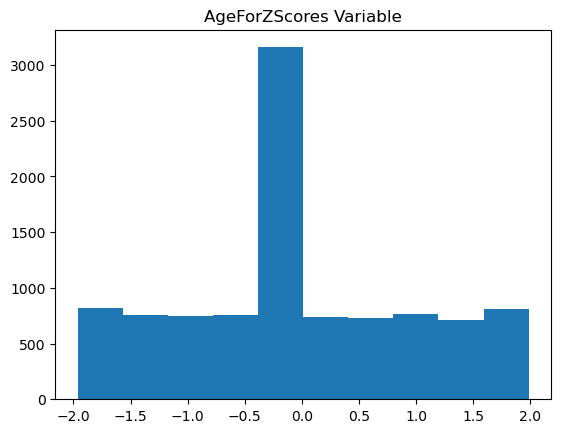

In [ ]:
# create visual for the Age Z-Scores
plt.hist(df_clean['AgeForZScores'])
plt.title('AgeForZScores Variable')
# plt.savefig('AgeForZScores Variable Distribution - Clean Data.png')
plt.show()

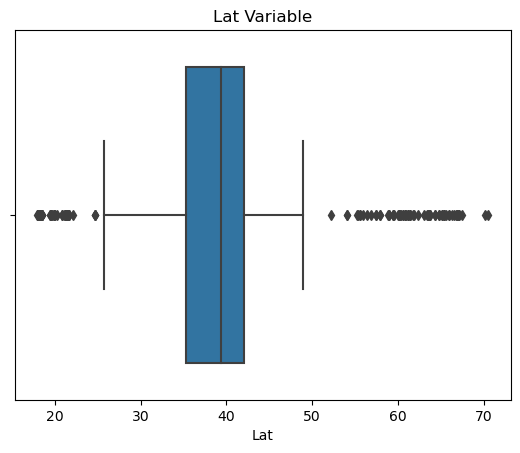

In [ ]:
Lat_boxplot = sns.boxplot(x = 'Lat', data = df_clean).set_title('Lat Variable')
# plt.savefig('Lat Boxplot.png')

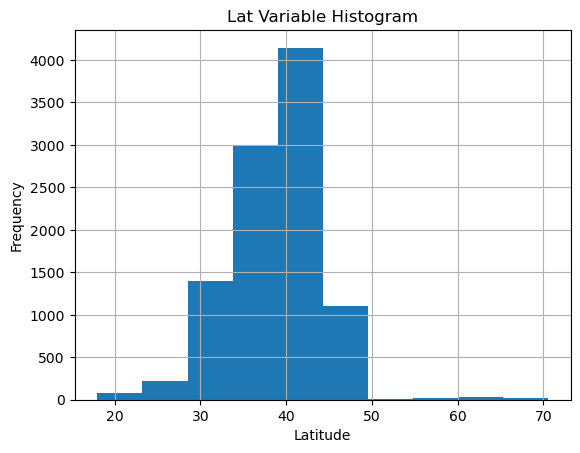

In [ ]:
# plot a histogram to identify outliers in the Lat variable
df_clean.hist(column = 'Lat')
plt.title('Lat Variable Histogram')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
# plt.savefig('Latitude Variable Histogram.png')
plt.show()

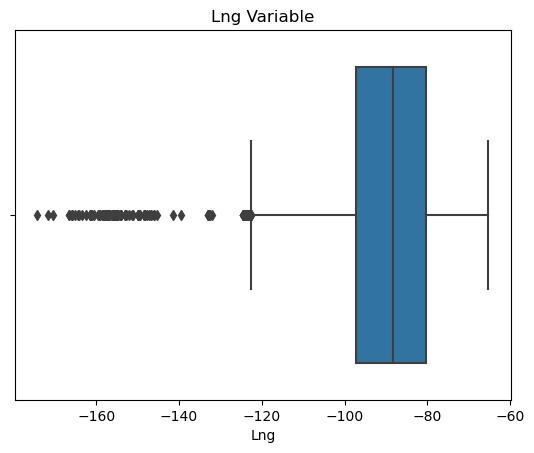

In [ ]:
Lng_boxplot = sns.boxplot(x = 'Lng', data = df_clean).set_title('Lng Variable')
# plt.savefig('Lng Boxplot.png')

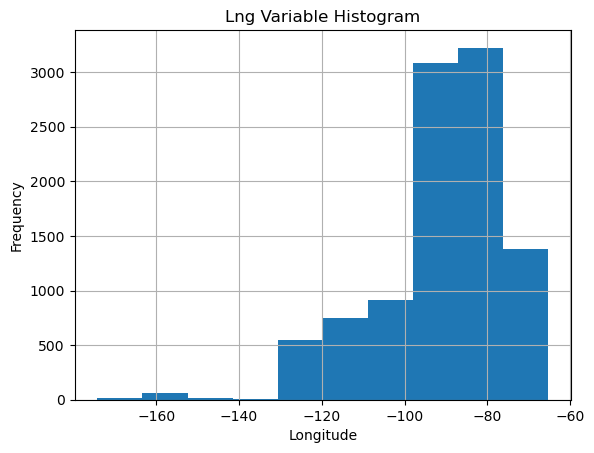

In [ ]:
# plot a histogram to identify outliers in the Lng variable
df_clean.hist(column = 'Lng')
plt.title('Lng Variable Histogram')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
# plt.savefig('Longitude Variable Histogram.png')
plt.show()

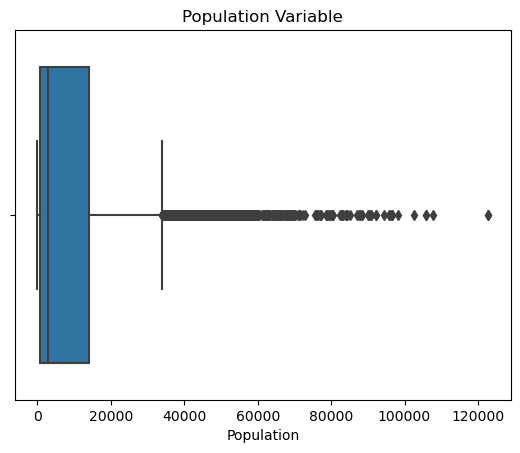

In [ ]:
Pop_boxplot = sns.boxplot(x = 'Population', data = df_clean).set_title('Population Variable')
# plt.savefig('Population Boxplot.png')

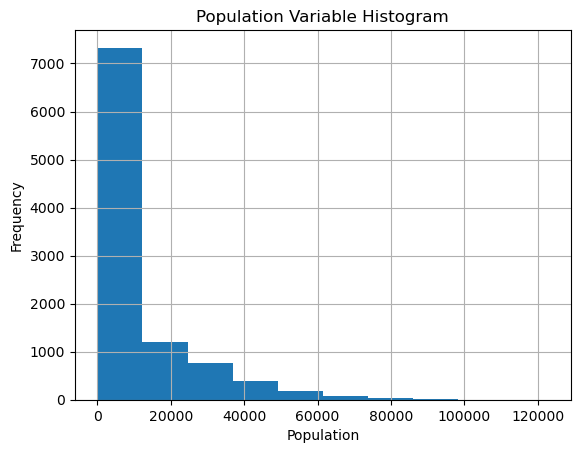

In [ ]:
# plot a histogram to identify outliers in the Population variable
df_clean.hist(column = 'Population')
plt.title('Population Variable Histogram')
plt.xlabel('Population')
plt.ylabel('Frequency')
# plt.savefig('Population Variable Histogram.png')
plt.show()

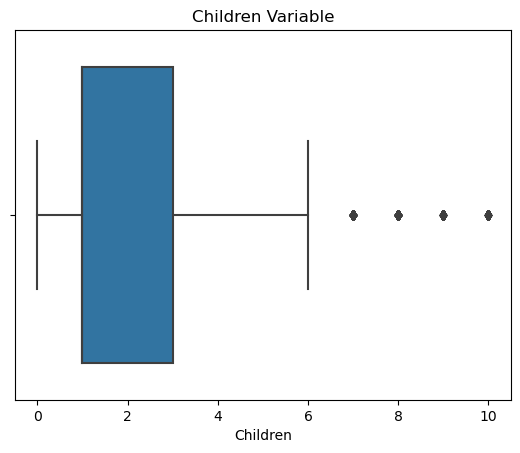

In [ ]:
Children_boxplot = sns.boxplot(x = 'Children', data = df_clean).set_title('Children Variable')
# plt.savefig('Children Boxplot.png')

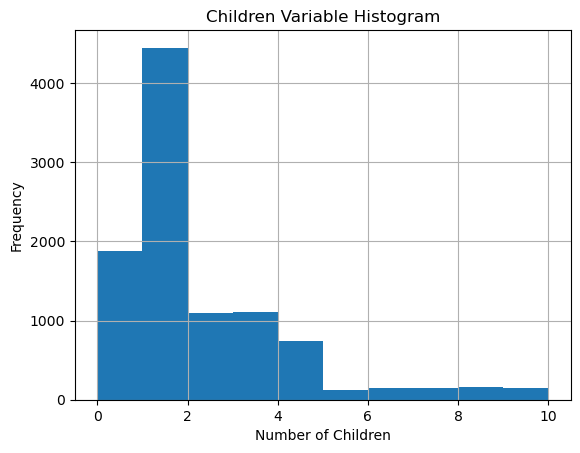

In [ ]:
# plot a histogram to identify outliers in the Children variable
df_clean.hist(column = 'Children')
plt.title('Children Variable Histogram')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
# plt.savefig('Children Variable Histogram.png')
plt.show()

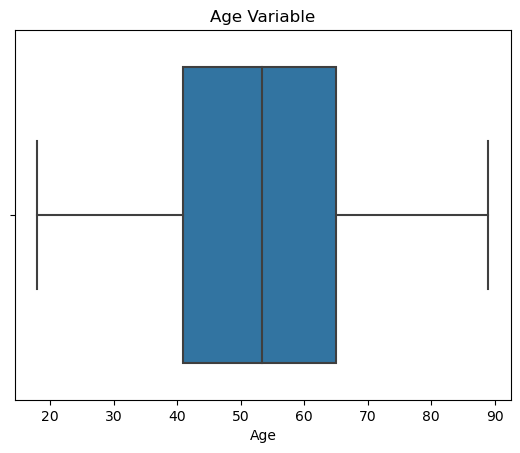

In [ ]:
Age_boxplot = sns.boxplot(x = 'Age', data = df_clean).set_title('Age Variable')
# plt.savefig('Age Boxplot.png')

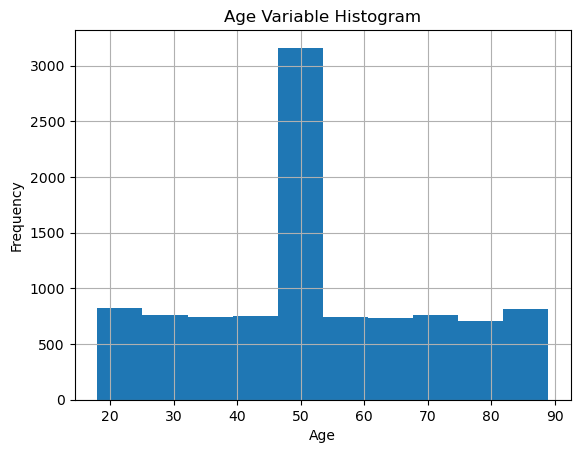

In [ ]:
# plot a histogram to identify outliers in the Age variable
df_clean.hist(column = 'Age')
plt.title('Age Variable Histogram')
plt.xlabel('Age')
plt.ylabel('Frequency')
# plt.savefig('Age Variable Histogram.png')
plt.show()

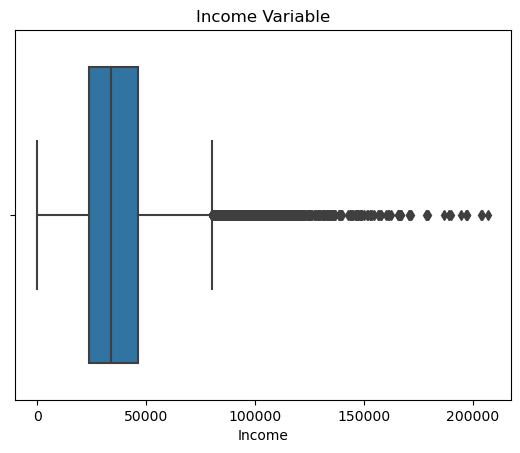

In [ ]:
Income_boxplot = sns.boxplot(x = 'Income', data = df_clean).set_title('Income Variable')
# plt.savefig('Income Boxplot.png')

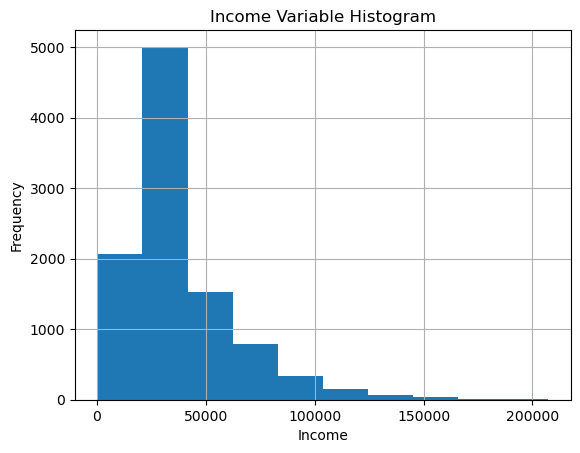

In [ ]:
# plot a histogram to identify outliers in the Income variable
df_clean.hist(column = 'Income')
plt.title('Income Variable Histogram')
plt.xlabel('Income')
plt.ylabel('Frequency')
# plt.savefig('Income Variable Histogram.png')
plt.show()

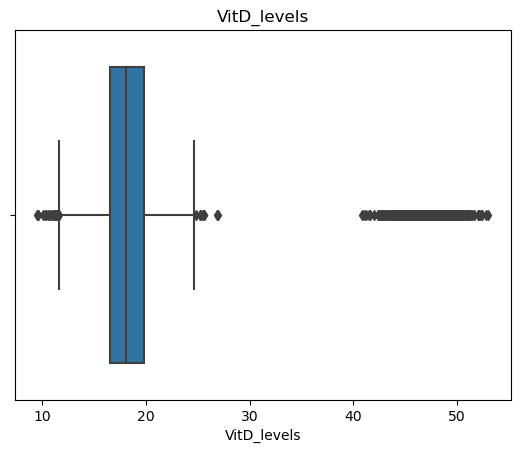

In [ ]:
VitD_lv_boxplot = sns.boxplot(x = 'VitD_levels', data = df_clean).set_title('VitD_levels')
# plt.savefig('VitD_levels Boxplot.png')

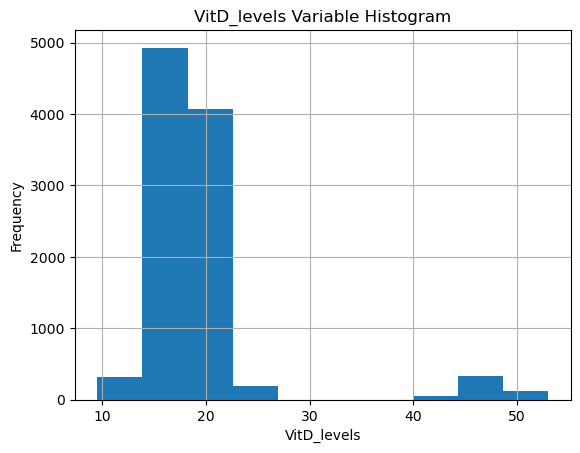

In [ ]:
# plot a histogram to identify outliers in the VitD_levels variable
df_clean.hist(column = 'VitD_levels')
plt.title('VitD_levels Variable Histogram')
plt.xlabel('VitD_levels')
plt.ylabel('Frequency')
# plt.savefig('VitD_levels Variable Histogram.png')
plt.show()

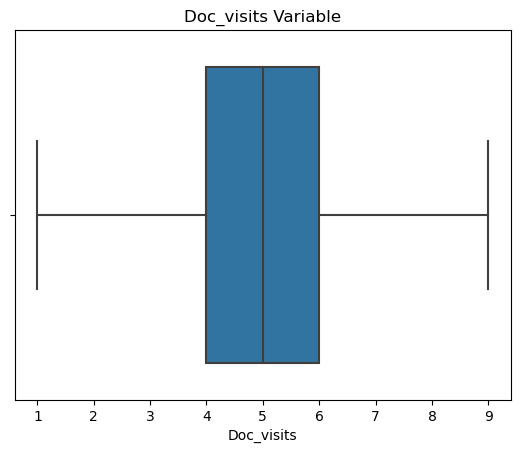

In [ ]:
Doc_visits_boxplot = sns.boxplot(x = 'Doc_visits', data = df_clean).set_title('Doc_visits Variable')
# plt.savefig('Doc_visits Boxplot.png')

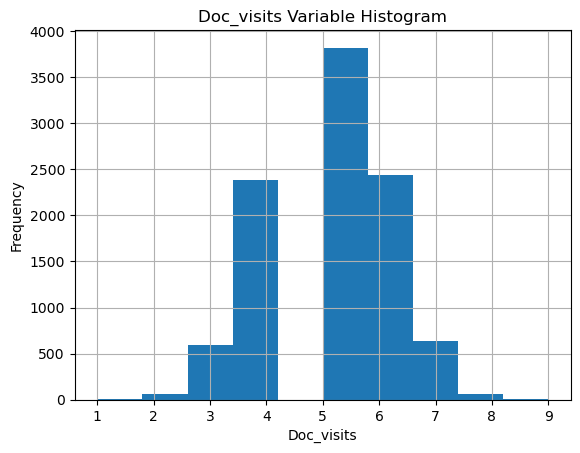

In [ ]:
# plot a histogram to identify outliers in the Doc_visits variable
df_clean.hist(column = 'Doc_visits')
plt.title('Doc_visits Variable Histogram')
plt.xlabel('Doc_visits')
plt.ylabel('Frequency')
# plt.savefig('Doc_visits Variable Histogram.png')
plt.show()

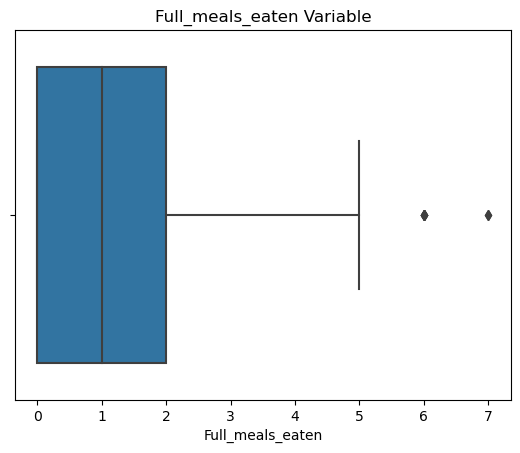

In [ ]:
Full_meals_boxplot = sns.boxplot(x = 'Full_meals_eaten', data = df_clean).set_title('Full_meals_eaten Variable')
# plt.savefig('Full_meals_eaten Boxplot.png')

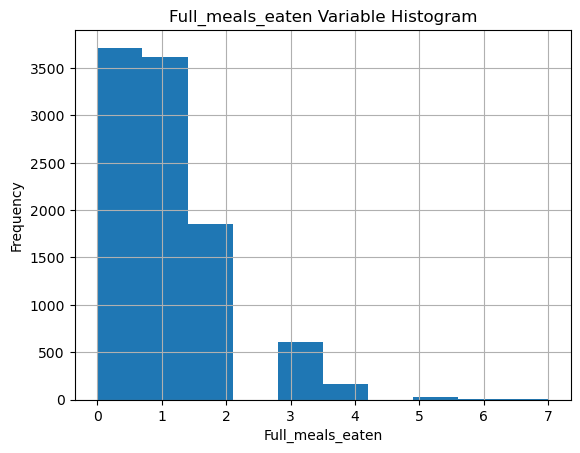

In [ ]:
# plot a histogram to identify outliers in the Full_meals_eaten variable
df_clean.hist(column = 'Full_meals_eaten')
plt.title('Full_meals_eaten Variable Histogram')
plt.xlabel('Full_meals_eaten')
plt.ylabel('Frequency')
# plt.savefig('Full_meals_eaten Variable Histogram.png')
plt.show()

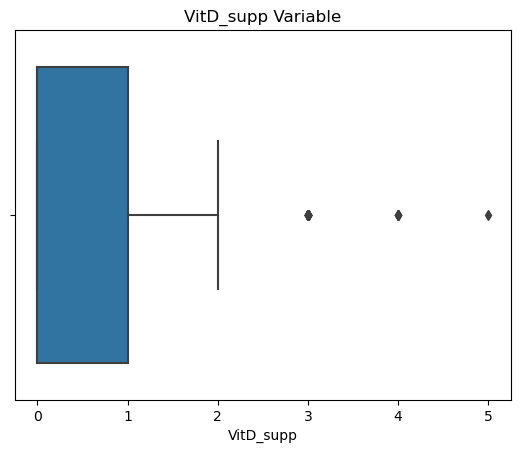

In [ ]:
VitD_supp_boxplot = sns.boxplot(x = 'VitD_supp', data = df_clean).set_title('VitD_supp Variable')
# plt.savefig('VitD_supp Boxplot.png')

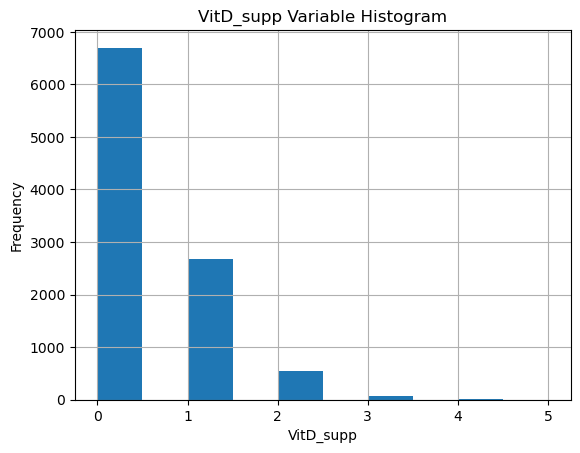

In [ ]:
# plot a histogram to identify outliers in the VitD_supp variable
df_clean.hist(column = 'VitD_supp')
plt.title('VitD_supp Variable Histogram')
plt.xlabel('VitD_supp')
plt.ylabel('Frequency')
# plt.savefig('VitD_supp Variable Histogram.png')
plt.show()

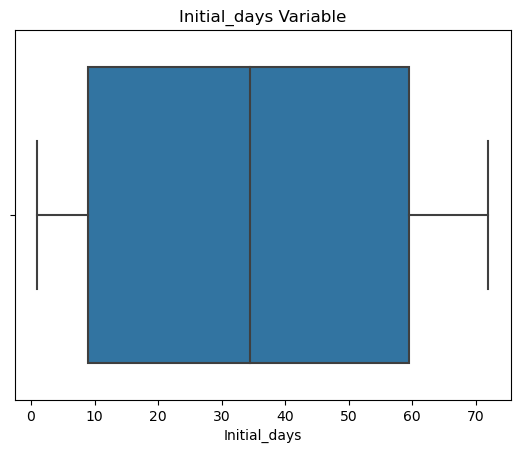

In [ ]:
Initial_days_boxplot = sns.boxplot(x = 'Initial_days', data = df_clean).set_title('Initial_days Variable')
# plt.savefig('Initial_days Boxplot.png')

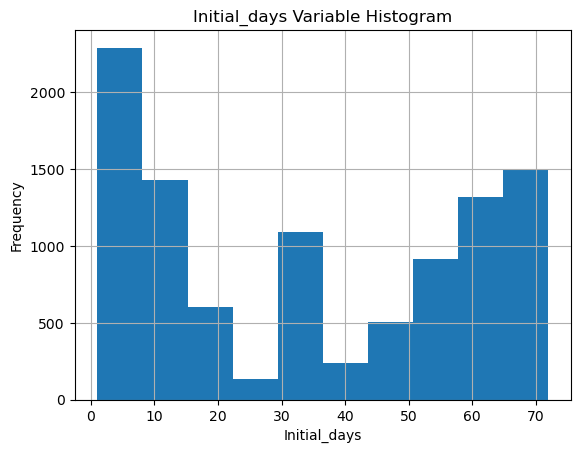

In [ ]:
# plot a histogram to identify outliers in the Initial_days variable
df_clean.hist(column = 'Initial_days')
plt.title('Initial_days Variable Histogram')
plt.xlabel('Initial_days')
plt.ylabel('Frequency')
# plt.savefig('Initial_days Variable Histogram.png')
plt.show()

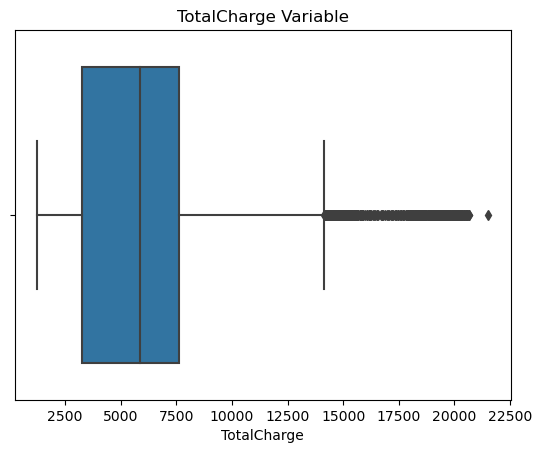

In [ ]:
Total_charge_boxplot = sns.boxplot(x = 'TotalCharge', data = df_clean).set_title('TotalCharge Variable')
# plt.savefig('TotalCharge Boxplot.png')

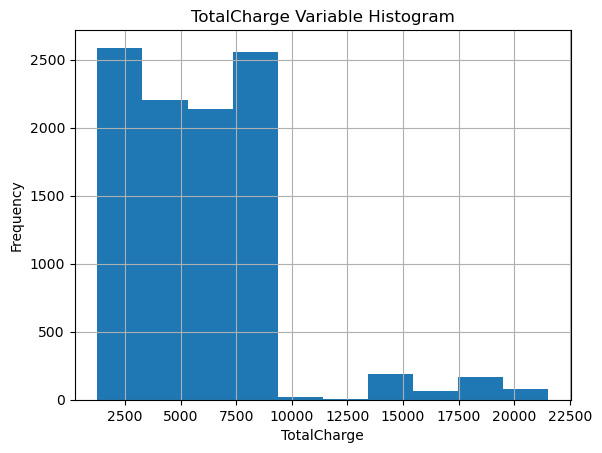

In [ ]:
# plot a histogram to identify outliers in the TotalCharge variable
df_clean.hist(column = 'TotalCharge')
plt.title('TotalCharge Variable Histogram')
plt.xlabel('TotalCharge')
plt.ylabel('Frequency')
# plt.savefig('TotalCharge Variable Histogram.png')
plt.show()

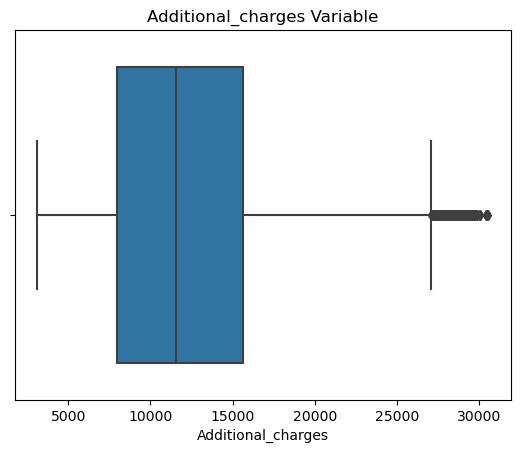

In [ ]:
Add_charge_boxplot = sns.boxplot(x = 'Additional_charges', data = df_clean).set_title('Additional_charges Variable')
# plt.savefig('Additional_charges Boxplot.png')

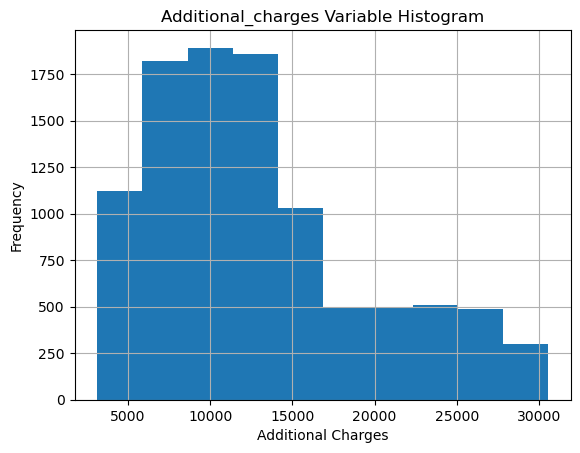

In [ ]:
# plot a histogram to identify outliers in the Additional_charges variable
df_clean.hist(column = 'Additional_charges')
plt.xlabel('Additional Charges')
plt.ylabel('Frequency')
plt.title('Additional_charges Variable Histogram')
# plt.savefig('Additional_charges Variable Histogram.png')
plt.show()

In [ ]:
# find the number (count) of outliers using query function
Children_query = df_clean.query('Children > 6')
Children_query.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 457 entries, 7 to 9999
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          457 non-null    int64  
 1   CaseOrder           457 non-null    int64  
 2   Customer_id         457 non-null    object 
 3   Interaction         457 non-null    object 
 4   UID                 457 non-null    object 
 5   City                457 non-null    object 
 6   State               457 non-null    object 
 7   County              457 non-null    object 
 8   Zip                 457 non-null    int64  
 9   Lat                 457 non-null    float64
 10  Lng                 457 non-null    float64
 11  Population          457 non-null    int64  
 12  Area                457 non-null    object 
 13  Timezone            457 non-null    object 
 14  Job                 457 non-null    object 
 15  Children            457 non-null    float64
 16  Age    

In [ ]:
# pd.set_option('display.max_rows',None)
df_clean[df_clean['Children']>6][['Age','Children']].sort_values(by='Age',ascending=True)

,Age,Children
4109,18.0,9.0
6282,18.0,7.0
1585,18.0,10.0
6417,18.0,8.0
1623,18.0,10.0
...,...,...
5732,89.0,8.0
6089,89.0,8.0
1609,89.0,7.0
3133,89.0,8.0


In [ ]:
# find the number (count) of outliers using query function
Full_meals_query = df_clean.query('Full_meals_eaten > 5')
Full_meals_query.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8 entries, 958 to 9986
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          8 non-null      int64  
 1   CaseOrder           8 non-null      int64  
 2   Customer_id         8 non-null      object 
 3   Interaction         8 non-null      object 
 4   UID                 8 non-null      object 
 5   City                8 non-null      object 
 6   State               8 non-null      object 
 7   County              8 non-null      object 
 8   Zip                 8 non-null      int64  
 9   Lat                 8 non-null      float64
 10  Lng                 8 non-null      float64
 11  Population          8 non-null      int64  
 12  Area                8 non-null      object 
 13  Timezone            8 non-null      object 
 14  Job                 8 non-null      object 
 15  Children            8 non-null      float64
 16  Age    

In [ ]:
# find the number (count) of outliers using query function
VitD_supp_query = df_clean.query('VitD_supp > 2')
VitD_supp_query.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70 entries, 62 to 9982
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          70 non-null     int64  
 1   CaseOrder           70 non-null     int64  
 2   Customer_id         70 non-null     object 
 3   Interaction         70 non-null     object 
 4   UID                 70 non-null     object 
 5   City                70 non-null     object 
 6   State               70 non-null     object 
 7   County              70 non-null     object 
 8   Zip                 70 non-null     int64  
 9   Lat                 70 non-null     float64
 10  Lng                 70 non-null     float64
 11  Population          70 non-null     int64  
 12  Area                70 non-null     object 
 13  Timezone            70 non-null     object 
 14  Job                 70 non-null     object 
 15  Children            70 non-null     float64
 16  Age    

# Treating outliers (imputation)

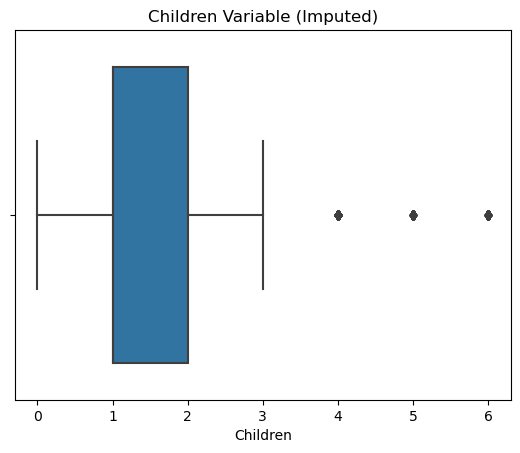

In [ ]:
# Replace outliers with NaN (null)
df_clean['Children'] = np.where(df_clean['Children'] > 6, np.nan, df_clean['Children'])

# Use the fillna function (impute with median)
df_clean['Children'].fillna(df_clean['Children'].median(), inplace = True)

# Plot the variables again for comparison (range after imputation)
children_imputed_boxplot = sns.boxplot(x = 'Children', data = df_clean).set_title('Children Variable (Imputed)')
# plt.savefig('Children Variable (Imputed).png')

In [ ]:
# find the number (count) of outliers using query function
Children_query = df_clean.query('Children > 3')
Children_query.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1010 entries, 10 to 9996
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1010 non-null   int64  
 1   CaseOrder           1010 non-null   int64  
 2   Customer_id         1010 non-null   object 
 3   Interaction         1010 non-null   object 
 4   UID                 1010 non-null   object 
 5   City                1010 non-null   object 
 6   State               1010 non-null   object 
 7   County              1010 non-null   object 
 8   Zip                 1010 non-null   int64  
 9   Lat                 1010 non-null   float64
 10  Lng                 1010 non-null   float64
 11  Population          1010 non-null   int64  
 12  Area                1010 non-null   object 
 13  Timezone            1010 non-null   object 
 14  Job                 1010 non-null   object 
 15  Children            1010 non-null   float64
 16  Age  

In [ ]:
# pd.set_option('display.max_rows',None)
df_clean[df_clean['Children']>3][['Age','Children']].sort_values(by='Age',ascending=True)

,Age,Children
9551,18.0,4.0
2836,18.0,4.0
7038,18.0,6.0
9973,18.0,4.0
3640,18.0,4.0
...,...,...
1336,89.0,4.0
2193,89.0,4.0
4143,89.0,5.0
536,89.0,4.0


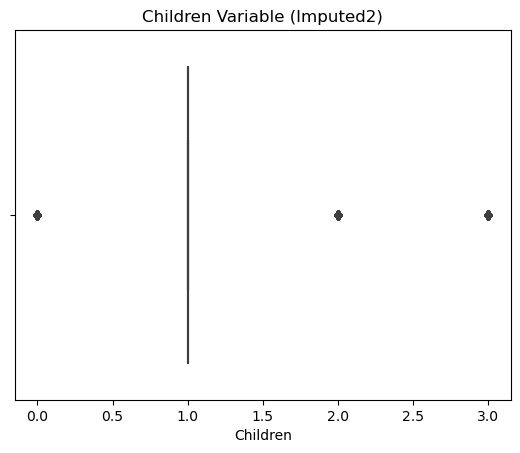

In [ ]:
# Replace outliers with NaN (null)
df_clean['Children'] = np.where(df_clean['Children'] > 3, np.nan, df_clean['Children'])

# Use the fillna function (impute with median)
df_clean['Children'].fillna(df_clean['Children'].median(), inplace = True)

# Plot the variables again for comparison (range after imputation)
children_imputed_boxplot = sns.boxplot(x = 'Children', data = df_clean).set_title('Children Variable (Imputed2)')
# plt.savefig('Children Variable (Imputed2).png')

In [ ]:
# pd.set_option('display.max_rows',None)
df_clean[df_clean['Children']==3][['Age','Children']].sort_values(by='Age',ascending=True)

,Age,Children
1065,18.0,3.0
4669,18.0,3.0
3187,18.0,3.0
4231,18.0,3.0
6339,18.0,3.0
...,...,...
6274,89.0,3.0
1465,89.0,3.0
2586,89.0,3.0
8088,89.0,3.0


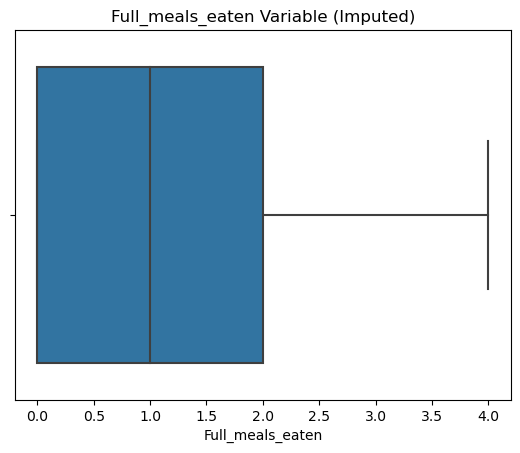

In [ ]:
# Replace outliers with NaN (null)
df_clean['Full_meals_eaten'] = np.where(df_clean['Full_meals_eaten'] > 4, np.nan, df_clean['Full_meals_eaten'])

# Use the fillna function (impute with median)
df_clean['Full_meals_eaten'].fillna(df_clean['Full_meals_eaten'].median(), inplace = True)

# Plot the variables again for comparison (range after imputation)
Full_meals_imputed_boxplot = sns.boxplot(x = 'Full_meals_eaten', data = df_clean).set_title('Full_meals_eaten Variable (Imputed)')
# plt.savefig('Full_meals_eaten Variable (Imputed).png')

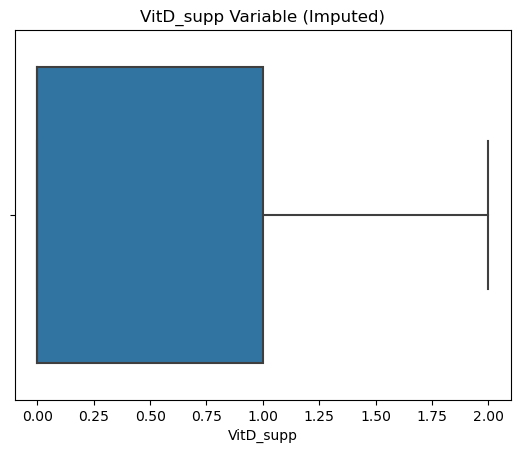

In [ ]:
# Replace outliers with NaN (null)
df_clean['VitD_supp'] = np.where(df_clean['VitD_supp'] > 2, np.nan, df_clean['VitD_supp'])

# Use the fillna function (impute with median)
df_clean['VitD_supp'].fillna(df_clean['VitD_supp'].median(), inplace = True)

# Plot the variables again for comparison (range after imputation)
VitD_supp_imputed_boxplot = sns.boxplot(x = 'VitD_supp', data = df_clean).set_title('VitD_supp Variable (Imputed)')
# plt.savefig('VitD_supp Variable (Imputed).png')

# Principal Component Analysis (PCA)
1) Import necessary libraries and packages
2) Define your variables for PCA
3) Normalize the data and apply PCA
4) Generate output of PCA loadings
5) Select PCs using scree plot

In [ ]:
# specify the variables for PCA (PCA only works for numeric, continuous values)
# store the variables in a new data frame
df_clean_PCA = df_clean[['Lat','Lng', 'Income','VitD_levels', 'Initial_days','TotalCharge','Additional_charges']]

# Normalize the data
df_clean_normalized = (df_clean_PCA-df_clean_PCA.mean())/df_clean_PCA.std()

# Apply PCA
pca = PCA(n_components=df_clean_PCA.shape[1])

# Fit the PCA to the dataset
pca.fit(df_clean_normalized)

PCA(n_components=7)

In [ ]:
# Convert the normalized data back into a dataframe
# Ensure all columns have appropriate labels
df_clean_PCA = pd.DataFrame(pca.transform(df_clean_normalized), columns = df_clean_PCA.columns)
df_clean_PCA

,Lat,Lng,Income,VitD_levels,Initial_days,TotalCharge,Additional_charges
0,-1.106794,-0.910500,1.219685,1.696839,-0.362797,0.172667,0.012094
1,-0.695869,-1.354649,0.881116,0.188076,-0.245522,0.755376,-0.022162
2,-1.460121,0.895650,0.906578,-1.132179,0.051099,-0.174532,0.088231
3,-1.484300,0.755056,0.684334,-0.064081,0.556887,-0.471904,-0.038153
4,-1.680408,-0.740246,-0.569707,-1.393248,1.685306,-0.190681,0.012523
...,...,...,...,...,...,...,...
9995,0.212694,-0.897215,-0.973308,0.343828,-0.084161,-0.394155,-0.093380
9996,1.020347,-0.632784,0.567527,-1.396502,-2.342445,-0.879413,0.172142
9997,0.096571,-0.550186,0.138282,1.003619,-0.592690,-0.050863,-0.675304
9998,1.236713,1.249352,-1.039965,-0.146705,0.204415,-0.215289,0.179956


In [ ]:
# PCA loadings
# extract PCA loading matrix
# name the dataframe loadings
# index the columns
loadings = pd.DataFrame(pca.components_.T, columns = ['PC1','PC2','PC3','PC4','PC5', 'PC6', 'PC7'], index = df_clean_PCA.columns)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Lat,-0.014968,0.707603,0.044093,-0.058467,0.056680,-0.700356,0.000028
Lng,-0.006570,-0.704407,0.001544,-0.123885,0.063494,-0.695977,0.001850
Income,-0.006431,-0.050713,0.157454,0.974757,-0.076571,-0.128759,-0.001029
VitD_levels,0.544282,-0.006094,0.451938,-0.027528,0.447202,0.049177,0.544340
Initial_days,0.450191,0.015749,-0.576560,0.048006,-0.503135,-0.074716,0.451250
TotalCharge,0.707031,0.003289,-0.006191,0.004137,0.007907,-0.011911,-0.706991
Additional_charges,0.029724,-0.015548,0.660723,-0.167340,-0.730544,-0.019899,0.015054


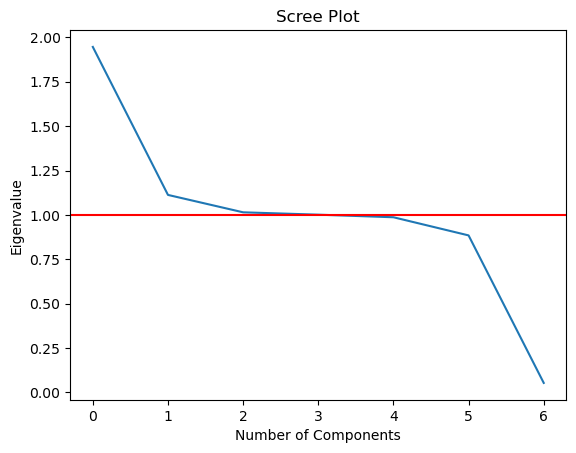

In [ ]:
# use the Kaiser Rule (Kaiser Criterion)
# calculate the covariance of the PCs by calculating the covariance matrix
cov_matrix = np.dot(df_clean_normalized.T, df_clean_normalized) / df_clean.shape[0]

eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]

# Plot the eigenvalues
plt.plot(eigenvalues)
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color="red")
plt.title('Scree Plot')
# plt.savefig('Scree Plot.png')
plt.show()

# Re-expression of Categorical Data

In [ ]:
# convert all categorical columns containing ordinal encoding
df_clean['Soft_drink'].replace([1,0],['Yes', 'No'], inplace = True)
df_clean['Soft_drink']

0        No
1        No
2        No
3        No
4       Yes
       ... 
9995     No
9996     No
9997    Yes
9998     No
9999     No
Name: Soft_drink, Length: 10000, dtype: object

In [ ]:
# convert all categorical columns containing ordinal encoding
df_clean['Overweight'].replace([1,0],['Yes', 'No'], inplace = True)
df_clean['Overweight']

0        No
1       Yes
2       Yes
3        No
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999    Yes
Name: Overweight, Length: 10000, dtype: object

In [ ]:
# convert all categorical columns containing ordinal encoding
df_clean['Anxiety'].replace([1,0],['Yes', 'No'], inplace = True)
df_clean['Anxiety']

0       Yes
1        No
2        No
3        No
4        No
       ... 
9995    Yes
9996     No
9997    Yes
9998     No
9999     No
Name: Anxiety, Length: 10000, dtype: object

# Treating Data Inconsistencies/Enhancing Data Clarity

In [ ]:
# rename columns to provide more information on data provided
df_clean.rename(columns={"Item1": "timely_admission","Item2": "timely_treatment","Item3": "timely_visits","Item4": "reliability","Item5": "options","Item6": "hrs_of_treatment","Item7": "courteous_staff","Item8": "active_listening"}, inplace=True)

In [ ]:
# round values as a whole number
df_clean['Children'] = df_clean['Children'].astype(int)
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Full_meals_eaten'] = df_clean['Full_meals_eaten'].astype(int)
df_clean['VitD_supp'] = df_clean['VitD_supp'].astype(int)

In [ ]:
# remove any negative values for variables where negative values cannot exist

# Data after it has been cleaned

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   CaseOrder           10000 non-null  int64  
 2   Customer_id         10000 non-null  object 
 3   Interaction         10000 non-null  object 
 4   UID                 10000 non-null  object 
 5   City                10000 non-null  object 
 6   State               10000 non-null  object 
 7   County              10000 non-null  object 
 8   Zip                 10000 non-null  int64  
 9   Lat                 10000 non-null  float64
 10  Lng                 10000 non-null  float64
 11  Population          10000 non-null  int64  
 12  Area                10000 non-null  object 
 13  Timezone            10000 non-null  object 
 14  Job                 10000 non-null  object 
 15  Children            10000 non-null  int32  
 16  Age  

In [ ]:
df_clean.shape

(10000, 54)

In [ ]:
df_clean.head()

,Unnamed: 0,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,Timezone,Job,Children,Age,Education,Employment,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,VitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,timely_admission,timely_treatment,timely_visits,reliability,options,hrs_of_treatment,courteous_staff,active_listening,AgeForZScores
0,1,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,"Some College, Less than 1 Year",Full Time,86575.93,Divorced,Male,No,17.802330,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3191.048774,17939.403420,3,3,2,2,4,3,3,4,-0.016433
1,2,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,"Some College, 1 or More Years, No Degree",Full Time,46805.99,Married,Female,No,18.994640,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4214.905346,17612.998120,3,4,3,4,4,4,3,3,-0.127591
2,3,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,"Some College, 1 or More Years, No Degree",Retired,14370.14,Widowed,Female,No,17.415889,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2177.586768,17505.192460,2,4,4,4,3,4,3,3,-0.016433
3,4,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,GED or Alternative Credential,Retired,39741.49,Married,Male,No,17.420079,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2465.118965,12993.437350,3,5,5,3,4,5,5,5,1.373036
4,5,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,Regular High School Diploma,Full Time,1209.56,Widowed,Female,No,16.870524,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,1885.655137,3716.525786,2,1,3,3,5,3,4,3,-1.739376


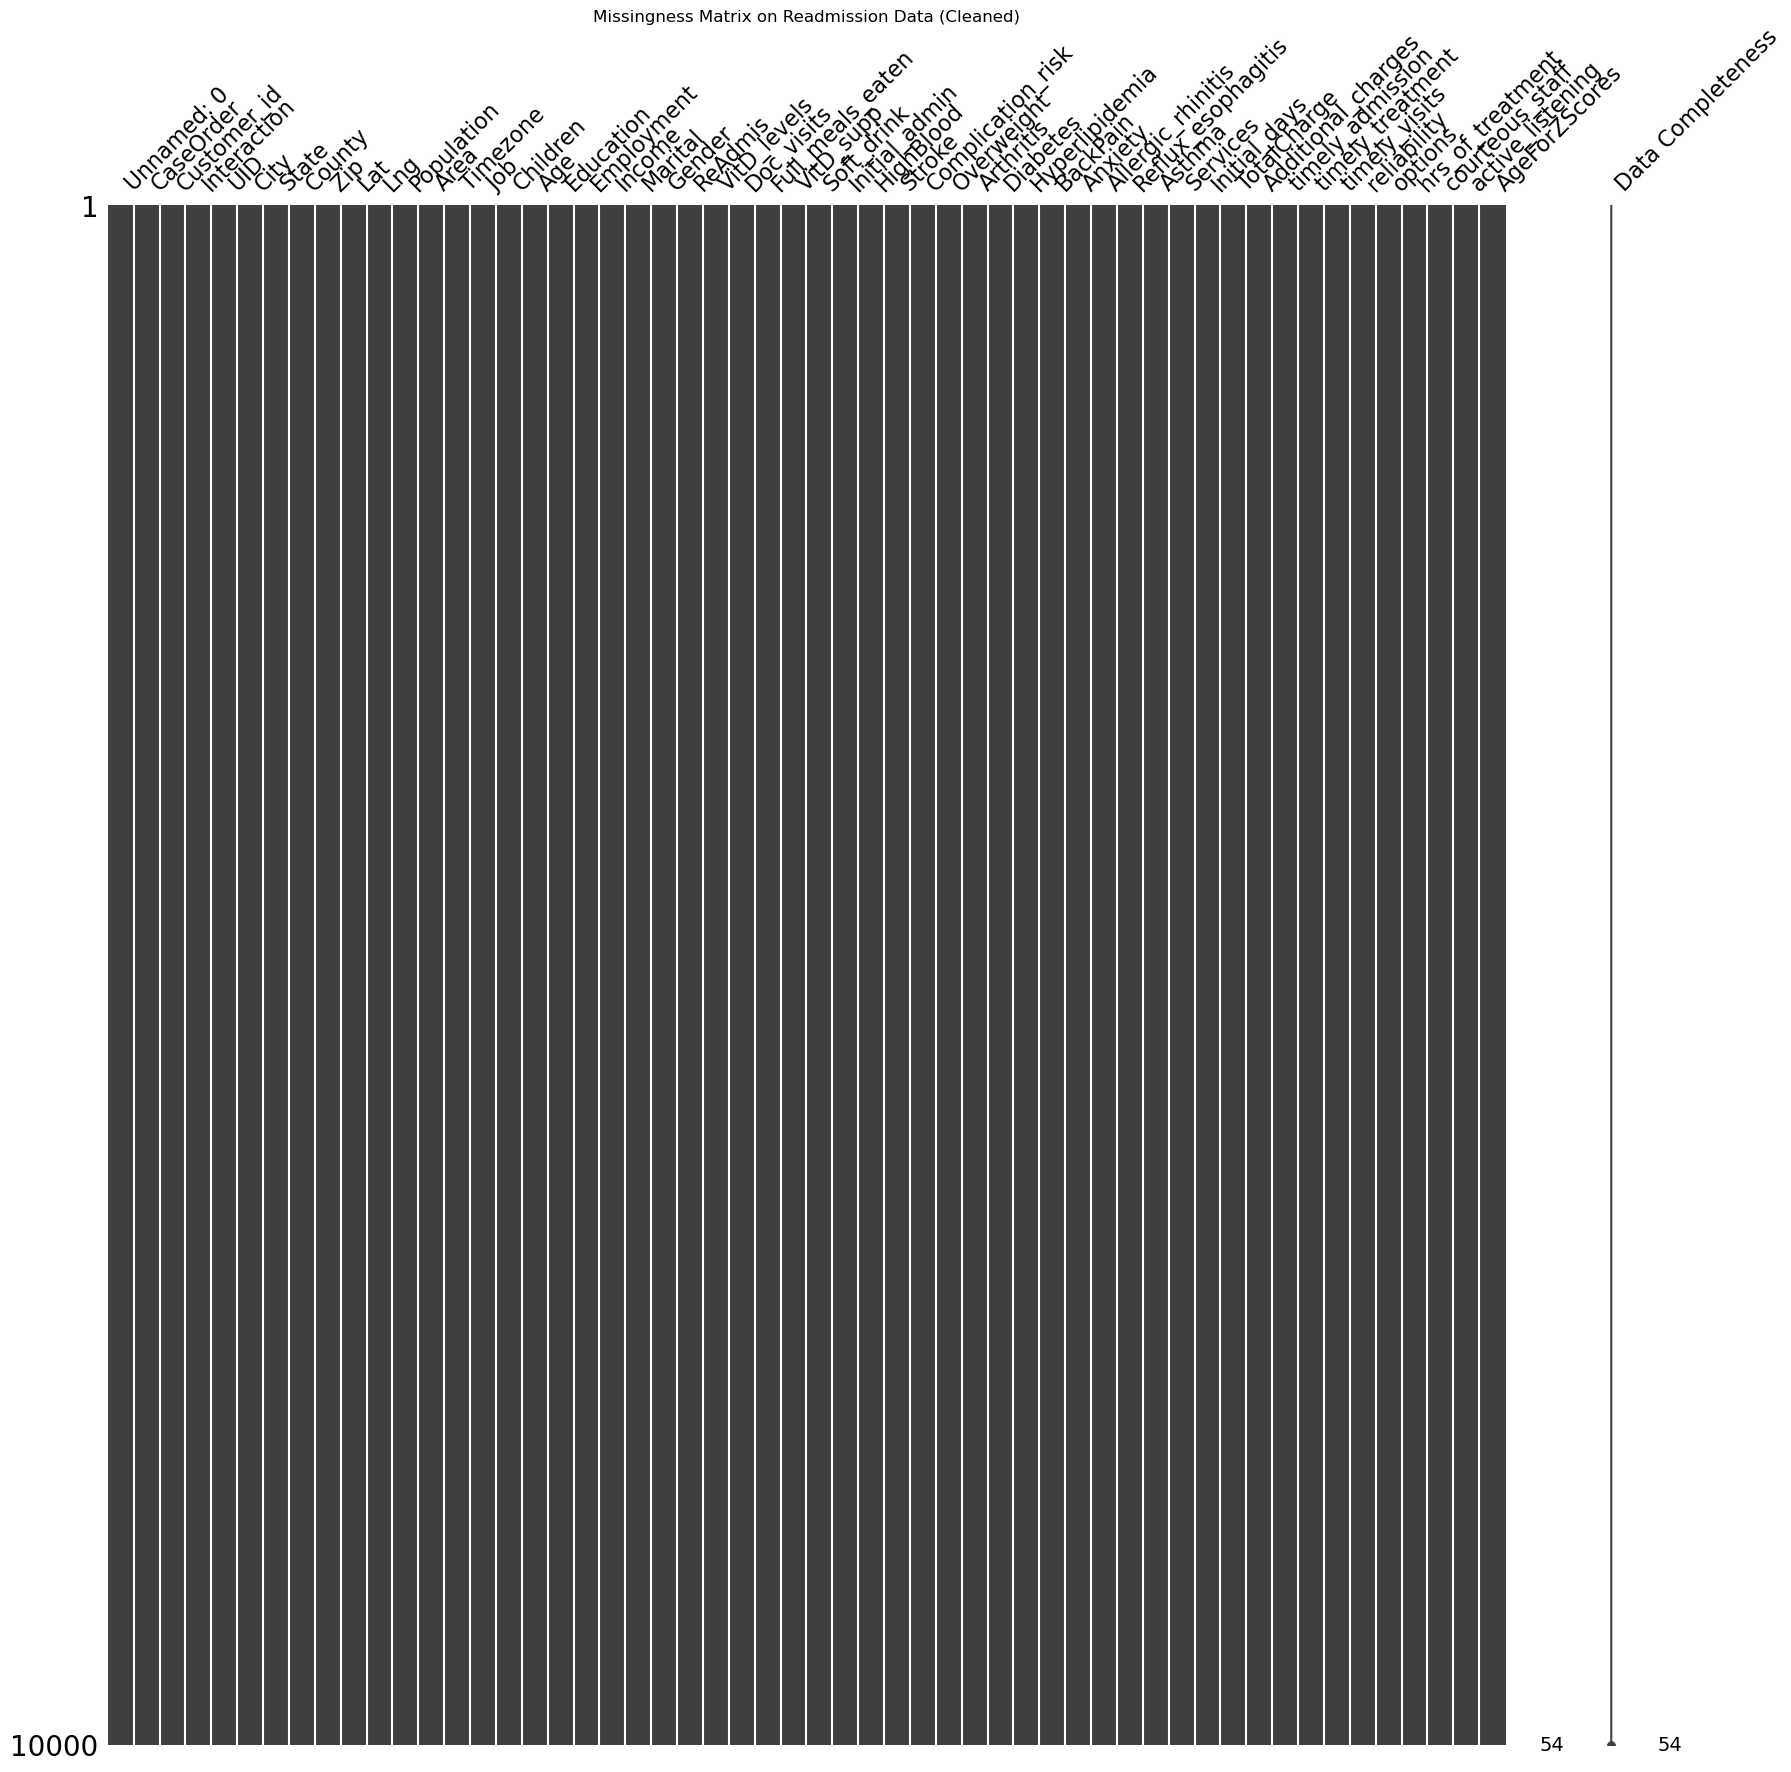

In [ ]:
# visualize missingness (after cleaning)
msno.matrix(df_clean, labels = True, figsize=(20,20))
plt.title('Missingness Matrix on Readmission Data (Cleaned)')
# plt.savefig('Missingness Matrix on Readmission Data (Cleaned).png')
plt.show()

In [ ]:
# Extract clean data 
df_clean.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\2. Data Cleaning with Python\Output\medical_clean_data.csv")